In [1]:
!pip install tabpfn shapiq xgboost statsmodels -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.8/50.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 753.2/753.2 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 82.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 370.9/370.9 kB 35.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


# Explainable At-Risk Student Prediction at KNUST: Integrating Academic Behaviour, Mental Health, and Ghana-Specific Contextual Barriers Using TabPFN v2 and Shapley Interaction Values
This notebook fulfills the methodological promises established in Section A of the manuscript.
It analyzes the primary survey data (N=422) using TabPFN v2 and Shapley Interaction Values (shapiq)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, f1_score, recall_score, precision_score
from statsmodels.stats.contingency_tables import mcnemar

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb
from tabpfn import TabPFNClassifier
from tabpfn.constants import ModelVersion
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')  # Required to pin V2 weights (Hollmann et al., 2025 Nature)

# Explainability
import shapiq

import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Calibration ─────────────────────────────────────────────
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss
import copy

Using device: cuda


## 1. Data Loading & Preprocessing
- Load `knust_synthetic_data.csv`
- Apply Data Exclusion Rules: drop rows with >2 missing values.
- Apply Median Imputation for remaining missing values.
- Check Spearman Collinearity (< 0.6 threshold)

Initial Shape: (422, 18)
Detected raw Google Forms export. Renaming columns and cleaning...
Cleaned Shape: (422, 16)
Shape after dropping >2 NaNs: (422, 16)


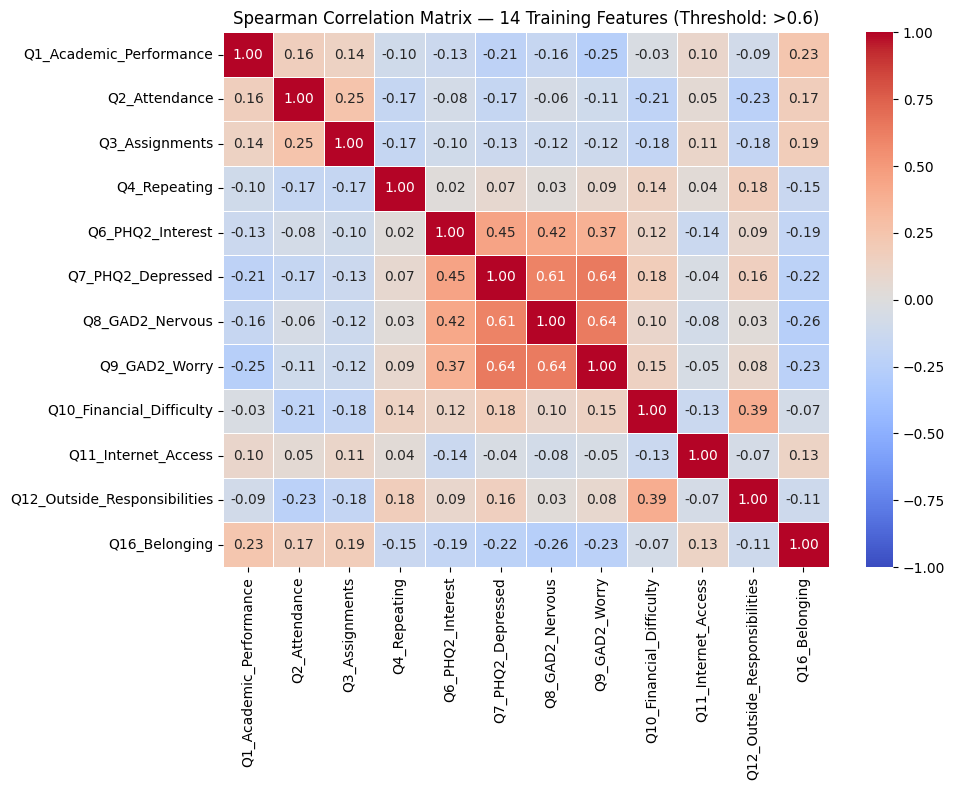

Highly correlated feature pairs (>0.6): [('Q7_PHQ2_Depressed', 'Q8_GAD2_Nervous'), ('Q7_PHQ2_Depressed', 'Q9_GAD2_Worry'), ('Q8_GAD2_Nervous', 'Q9_GAD2_Worry')]


In [4]:
# ── [3A] Load Data with Real/Synthetic Toggle ─────────────────────────────────
# Set USE_RAW_DATA = True to replicate results on real survey data locally.
# For public replication, set to False to use the synthetic dataset.
USE_RAW_DATA = False

if USE_RAW_DATA:
    data_path = r'C:\Users\elzor\Downloads\knust_real_data.csv'
else:
    data_path = '../data/synthetic_knust_data.csv'

df = pd.read_csv(data_path)
print(f'Initial Shape: {df.shape}')

# Check if it is the raw Google Forms export (with 18 columns)
if df.shape[1] == 18 or 'Timestamp' in df.columns:
    print("Detected raw Google Forms export. Renaming columns and cleaning...")
    # Drop metadata columns
    cols_to_drop = ['Timestamp', '  If you selected Other Faculty, please specify your faculty or school.  ']
    df = df.drop(columns=cols_to_drop, errors='ignore')

    # Rename columns to standard 16-feature keys in the exact order
    standard_columns = [
        'Q1_Academic_Performance', 'Q2_Attendance', 'Q3_Assignments', 'Q4_Repeating',
        'Q5_Withdrawal_Intention', 'Q6_PHQ2_Interest', 'Q7_PHQ2_Depressed', 'Q8_GAD2_Nervous',
        'Q9_GAD2_Worry', 'Q10_Financial_Difficulty', 'Q11_Internet_Access', 'Q12_Outside_Responsibilities',
        'Q13_Faculty', 'Q14_Year', 'Q15_Gender', 'Q16_Belonging'
    ]
    df.columns = standard_columns
    print(f'Cleaned Shape: {df.shape}')

# 1. Exclusion Rule: Drop rows with >2 missing values (proposal §4.2)
missing_counts = df.isnull().sum(axis=1)
df = df[missing_counts <= 2].copy()
print(f'Shape after dropping >2 NaNs: {df.shape}')

TARGET_COL    = 'Q5_Withdrawal_Intention'
FAIRNESS_COLS = ['Q15_Gender', 'Q13_Faculty', 'Q14_Year']
ORDINAL_MAPS = {
    'Q1_Academic_Performance': {
        'Excellent': 4, 'Good': 3, 'Average': 2,
        'Below average': 1, 'Below Average': 1,            # Google Forms capitalises 'Average'
        'Struggling significantly': 0, 'Struggling Significantly': 0  # and 'Significantly'
    },
    'Q2_Attendance': {
        'More than 80%': 3, '60–80%': 2, '40–60%': 1, 'Less than 40%': 0
    },
    'Q3_Assignments': {
        'All 5': 4, '3 or 4': 3, '1 or 2': 2, 'None': 1
    },
    'Q4_Repeating': {'Yes': 1, 'No': 0},
    'Q6_PHQ2_Interest': {
        'Not at all': 0, 'Several days': 1,
        'More than half the days': 2, 'Nearly every day': 3
    },
    'Q7_PHQ2_Depressed': {
        'Not at all': 0, 'Several days': 1,
        'More than half the days': 2, 'Nearly every day': 3
    },
    'Q8_GAD2_Nervous': {
        'Not at all': 0, 'Several days': 1,
        'More than half the days': 2, 'Nearly every day': 3
    },
    'Q9_GAD2_Worry': {
        'Not at all': 0, 'Several days': 1,
        'More than half the days': 2, 'Nearly every day': 3
    },
    'Q10_Financial_Difficulty': {
        'Not at all': 0,
        'Slightly — it has rarely affected my participation': 1,
        'Moderately — it has sometimes limited my participation': 2,
        'Severely — it has significantly limited my participation': 3
    },
    'Q11_Internet_Access': {
        'Very limited — a serious barrier to my studies': 0,
        'Frequently unreliable — regular difficulties': 1,
        'Mostly reliable — occasional difficulties': 2,
        'Reliable access — rarely a problem': 3
    },
    'Q12_Outside_Responsibilities': {
        'No — these do not significantly affect my study time': 0,
        'Sometimes — these occasionally affect my study time': 1,
        'Yes — these regularly take significant time from my studies': 2
    },
    'Q13_Faculty': {
        'College of Engineering': 1, 'College of Science': 2,
        'College of Arts and Social Sciences': 3, 'School of Business': 4,
        'College of Health Sciences': 5,
        'Other (please specify):': 6, 'Other Faculty': 6  # Google Forms uses 'Other Faculty'
    },
    'Q14_Year': {
        'Year 1': 1, 'Year 2': 2, 'Year 3': 3, 'Year 4': 4,
        'Year 5 or above (undergraduate)': 5, 'Postgraduate (Masters or PhD)': 6
    },
    'Q15_Gender': {
        'Male': 1, 'Female': 0,
        'Prefer not to say': np.nan  # NaN: excluded from gender subgroup in fairness analysis
    },
    'Q16_Belonging': {
        'Strongly disagree — I rarely feel I belong here': 0,
        'Disagree — I often feel I do not belong here': 1,
        'Neutral': 2,
        'Agree — I mostly feel I belong here': 3,
        'Strongly agree — I feel I belong here': 4
    }
}

df_encoded = df.copy()
for col, mapping in ORDINAL_MAPS.items():
    if col in df_encoded.columns:
        df_encoded[col] = df_encoded[col].map(mapping)

# Sanity check: flag any CSV strings not covered by ORDINAL_MAPS
unmapped = {}
for col in ORDINAL_MAPS:
    if col in df_encoded.columns and col != TARGET_COL:
        leftovers = df_encoded[col].isna() & df[col].notna()
        if leftovers.any():
            unmapped[col] = df.loc[leftovers, col].unique().tolist()
if unmapped:
    print(f'WARNING: unmapped values found — check ORDINAL_MAPS: {unmapped}')
else:
    print('Encoding check passed — all survey responses mapped correctly.')

# 3. Median Imputation for missing values (proposal §4.2)
# Applied to the 14 training features only; Q15 handled separately below.
training_feature_cols = [c for c in df_encoded.columns
                         if c not in [TARGET_COL] + FAIRNESS_COLS]
imputer = SimpleImputer(strategy='median')
df_encoded[training_feature_cols] = imputer.fit_transform(
    df_encoded[training_feature_cols]
)

# Impute Q15 separately (median of Male=1 / Female=0 only)
df_encoded['Q15_Gender'] = df_encoded['Q15_Gender'].fillna(
    df_encoded['Q15_Gender'].median()
)

# 4. Spearman Collinearity Check — 14 training features only (proposal §4.5)
# Q15_Gender excluded: it is a fairness-only variable, not a training feature.
plt.figure(figsize=(10, 8))
corr_matrix = df_encoded[training_feature_cols].corr(method='spearman')
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5, linecolor='white')
plt.title('Spearman Correlation Matrix — 14 Training Features (Threshold: >0.6)')
plt.tight_layout()
plt.show()

high_corr = np.where((np.abs(corr_matrix) > 0.6) & (corr_matrix != 1.0))
high_corr_pairs = [(corr_matrix.columns[x], corr_matrix.columns[y])
                   for x, y in zip(*high_corr) if x < y]
print(f'Highly correlated feature pairs (>0.6): {high_corr_pairs}')

## 2. Exploratory Data Analysis — Sample Demographics
Participant profile: Faculty, Year of Study, and Gender distributions.

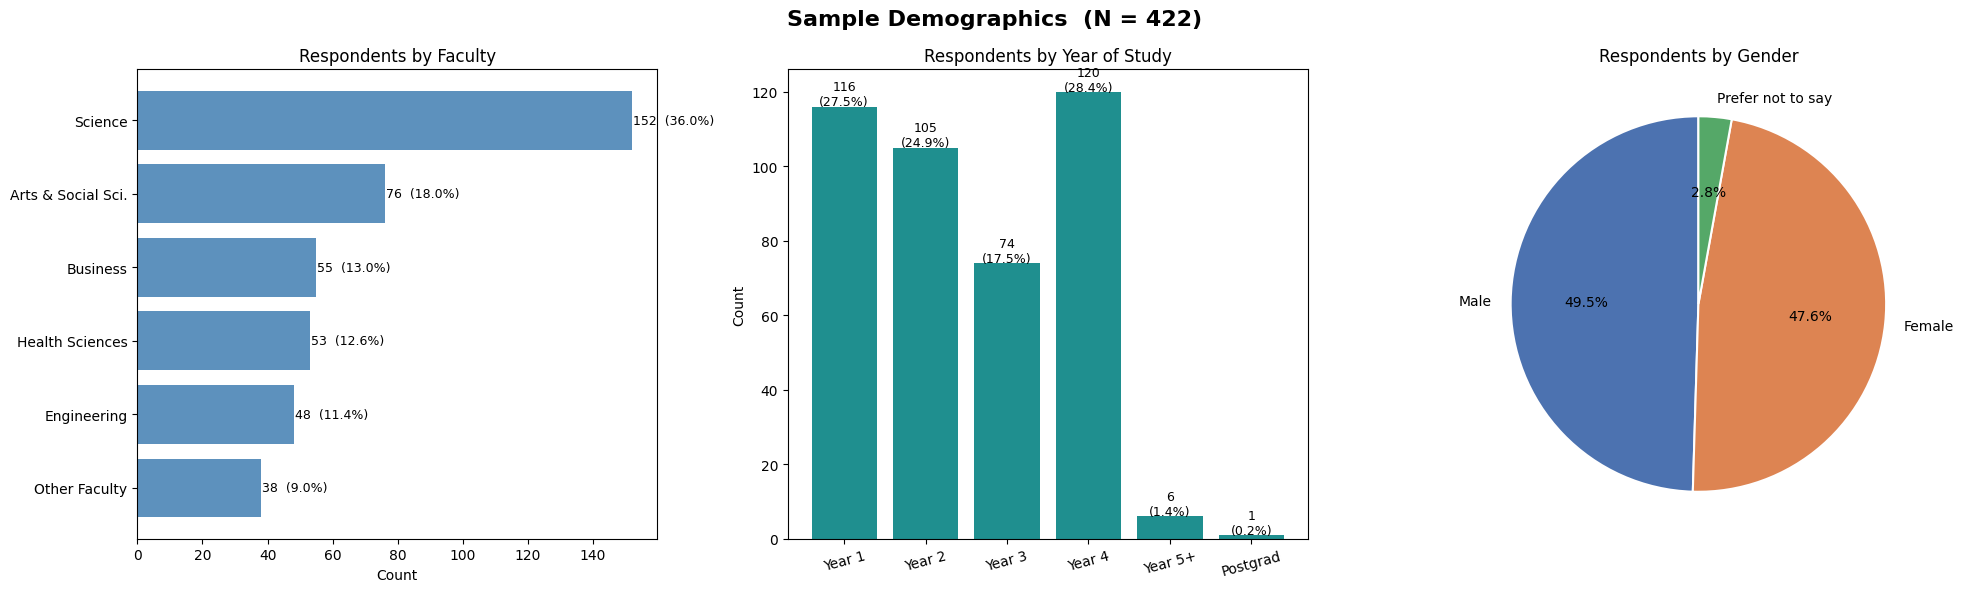

Faculty breakdown:
Q13_Faculty
College of Science                     152
College of Arts and Social Sciences     76
School of Business                      55
College of Health Sciences              53
College of Engineering                  48
Other Faculty                           38

Year breakdown:
Q14_Year
Year 4                             120
Year 1                             116
Year 2                             105
Year 3                              74
Year 5 or above (undergraduate)      6
Postgraduate (Masters or PhD)        1

Gender breakdown:
Q15_Gender
Male                 209
Female               201
Prefer not to say     12


In [5]:
# Faculty short-name map
_SHORT_D = {
    'College of Engineering': 'Engineering',
    'College of Science': 'Science',
    'College of Arts and Social Sciences': 'Arts & Social Sci.',
    'School of Business': 'Business',
    'College of Health Sciences': 'Health Sciences',
    'Other (please specify):': 'Other'
}
_YEAR_ORD = ['Year 1','Year 2','Year 3','Year 4',
             'Year 5 or above (undergraduate)','Postgraduate (Masters or PhD)']
_YEAR_LBL = ['Year 1','Year 2','Year 3','Year 4','Year 5+','Postgrad']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle(f'Sample Demographics  (N = {len(df)})', fontsize=16, fontweight='bold')

# Faculty
_fac_d = df['Q13_Faculty'].value_counts()
_fac_d.index = _fac_d.index.map(lambda x: _SHORT_D.get(x, x))
_fac_d = _fac_d.sort_values(ascending=True)
_bars_d0 = axes[0].barh(_fac_d.index, _fac_d.values, color='steelblue', alpha=0.88)
axes[0].set_title('Respondents by Faculty')
axes[0].set_xlabel('Count')
for bar, v in zip(_bars_d0, _fac_d.values):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{v}  ({v/len(df)*100:.1f}%)', va='center', fontsize=9)

# Year of Study
_yr_d = df['Q14_Year'].value_counts().reindex(_YEAR_ORD).fillna(0).astype(int)
_bars_d1 = axes[1].bar(_YEAR_LBL, _yr_d.values, color='teal', alpha=0.88)
axes[1].set_title('Respondents by Year of Study')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=15)
for bar, v in zip(_bars_d1, _yr_d.values):
    axes[1].text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.3,
                 f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontsize=9)

# Gender
_gen_d = df['Q15_Gender'].value_counts()
_pie_colors = ['#4C72B0', '#DD8452', '#55A868'][:len(_gen_d)]
axes[2].pie(_gen_d.values, labels=_gen_d.index, autopct='%1.1f%%',
            colors=_pie_colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[2].set_title('Respondents by Gender')

plt.tight_layout()
plt.savefig('fig_demographics.png', dpi=150, bbox_inches='tight')
plt.show()

print('Faculty breakdown:')
print(df['Q13_Faculty'].value_counts().to_string())
print('\nYear breakdown:')
print(df['Q14_Year'].value_counts().to_string())
print('\nGender breakdown:')
print(df['Q15_Gender'].value_counts().to_string())

## 2. Thresholding Sensitivity Analysis
We threshold Q5: "Yes" and "Sometimes" = 1 (At-Risk), "No" = 0.
We evaluate the sensitivity of TabPFN at probability cutoffs 0.4, 0.5, and 0.6.

In [6]:
import os
# Authenticate TabPFN (required to download V2 weights on first run)
os.environ['TABPFN_TOKEN'] = (
    'eyJhbGciOiJIUzI1NiIsInR5cCI6IkpXVCJ9'
    '.eyJ1c2VyIjoiOTU0MTQ4YTEtOTViYy00MDQ1LTg0ZTgtOTg2NDkxN2RjOGNiIiwiZXhwIjoxODA5NjExOTcxfQ'
    '.JttPfrljKA-ZKigdc9KCB0qZYytjNyaMIA0HzsxyAoA'
)

# Build Binary Target  (Q5 — proposal §4.2)
target_mapping = {
    'No': 0,
    'I have thought about it briefly but not seriously': 1,
    'Yes, I have seriously considered this': 1
}
y_series = df[TARGET_COL].map(target_mapping)

# Guard: drop rows where Q5 is blank or unrecognised before stratified split
nan_target = y_series.isna()
if nan_target.any():
    print(f'Warning: {nan_target.sum()} rows with missing/unmapped Q5 dropped.')
    valid_idx  = y_series.dropna().index
    df         = df.loc[valid_idx].reset_index(drop=True)
    df_encoded = df_encoded.loc[valid_idx].reset_index(drop=True)
    y_series   = y_series.dropna().reset_index(drop=True)

y = y_series.values.astype(int)
print(f'Class distribution — At-risk (1): {y.sum()} | Not at-risk (0): {(y==0).sum()}')

# Feature matrix: 14 training features (Q15 dropped — fairness-only, proposal §4.2)
X_df = df_encoded.drop(columns=[TARGET_COL, 'Q15_Gender'])
X    = X_df.values.astype(float)

# Stratified 80/20 train-test split  (random_state=42, proposal §4.2)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Training: {len(X_train)} samples ({y_train.sum()} at-risk)')
print(f'Testing:  {len(X_test)}  samples ({y_test.sum()}  at-risk)')

# TabPFN v2 — Zero-shot configuration
# Pinned to ModelVersion.V2 (Hollmann et al., 2025, Nature 637, 319-326)
# device=device ensures cross-environment reproducibility (proposal §4.5)
tabpfn_model = TabPFNClassifier.create_default_for_version(
    ModelVersion.V2, device=device, random_state=42
)
tabpfn_model.fit(X_train, y_train)

# Threshold Sensitivity Analysis  (proposal §4.2 — 0.4 / 0.5 / 0.6 cutoffs)
probs = tabpfn_model.predict_proba(X_test)[:, 1]

print('\nThreshold Sensitivity Analysis — TabPFN v2')
for thresh in [0.4, 0.5, 0.6]:
    preds = (probs >= thresh).astype(int)
    rec   = recall_score(y_test, preds, zero_division=0)
    prec  = precision_score(y_test, preds, zero_division=0)
    f1    = f1_score(y_test, preds, zero_division=0)
    print(f'  Threshold {thresh}: Recall={rec:.3f}  Precision={prec:.3f}  F1={f1:.3f}')

Class distribution — At-risk (1): 159 | Not at-risk (0): 263
Training: 337 samples (127 at-risk)
Testing:  85  samples (32  at-risk)


tabpfn-v2-classifier-finetuned-zk73skhh.(…):   0%|          | 0.00/29.0M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/37.0 [00:00<?, ?B/s]


Threshold Sensitivity Analysis — TabPFN v2
  Threshold 0.4: Recall=0.750  Precision=0.632  F1=0.686
  Threshold 0.5: Recall=0.562  Precision=0.643  F1=0.600
  Threshold 0.6: Recall=0.438  Precision=0.609  F1=0.509


### Target Variable Distribution
Withdrawal intention before and after binarisation.

Class imbalance ratio: 263:159  (1.65:1)  → justifies class_weight=balanced / scale_pos_weight


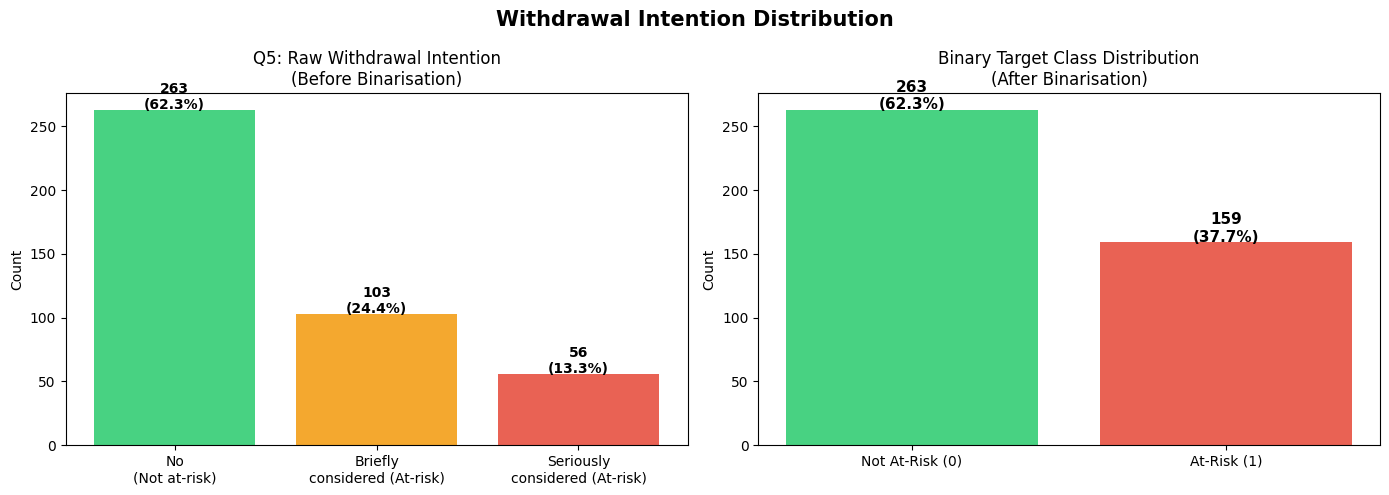

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Withdrawal Intention Distribution', fontsize=15, fontweight='bold')

# --- Raw Q5 (3-way before binarising) ---
_q5_order = [
    'No',
    'I have thought about it briefly but not seriously',
    'Yes, I have seriously considered this'
]
_q5_counts = df['Q5_Withdrawal_Intention'].value_counts().reindex(_q5_order).fillna(0).astype(int)
_q5_labels = ['No\n(Not at-risk)', 'Briefly\nconsidered (At-risk)', 'Seriously\nconsidered (At-risk)']
_q5_colors = ['#2ecc71', '#f39c12', '#e74c3c']
_bars_q5 = axes[0].bar(_q5_labels, _q5_counts.values, color=_q5_colors, alpha=0.88)
axes[0].set_title('Q5: Raw Withdrawal Intention\n(Before Binarisation)', fontsize=12)
axes[0].set_ylabel('Count')
for bar, v in zip(_bars_q5, _q5_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                 f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold', fontsize=10)

# --- Binary target ---
_class_counts = pd.Series(y).value_counts().sort_index()
_cls_labels = ['Not At-Risk (0)', 'At-Risk (1)']
_cls_colors = ['#2ecc71', '#e74c3c']
_bars_cls = axes[1].bar(_cls_labels, _class_counts.values, color=_cls_colors, alpha=0.88)
axes[1].set_title('Binary Target Class Distribution\n(After Binarisation)', fontsize=12)
axes[1].set_ylabel('Count')
for bar, v in zip(_bars_cls, _class_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                 f'{v}\n({v/len(y)*100:.1f}%)', ha='center', fontweight='bold', fontsize=11)

print(f'Class imbalance ratio: {_class_counts[0]:.0f}:{_class_counts[1]:.0f}  '
      f'({_class_counts[0]/_class_counts[1]:.2f}:1)  '
      f'→ justifies class_weight=balanced / scale_pos_weight')
plt.tight_layout()
plt.savefig('fig_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### At-Risk Rate by Demographic Group
Prevalence of at-risk status across Faculty, Year of Study, and Gender.

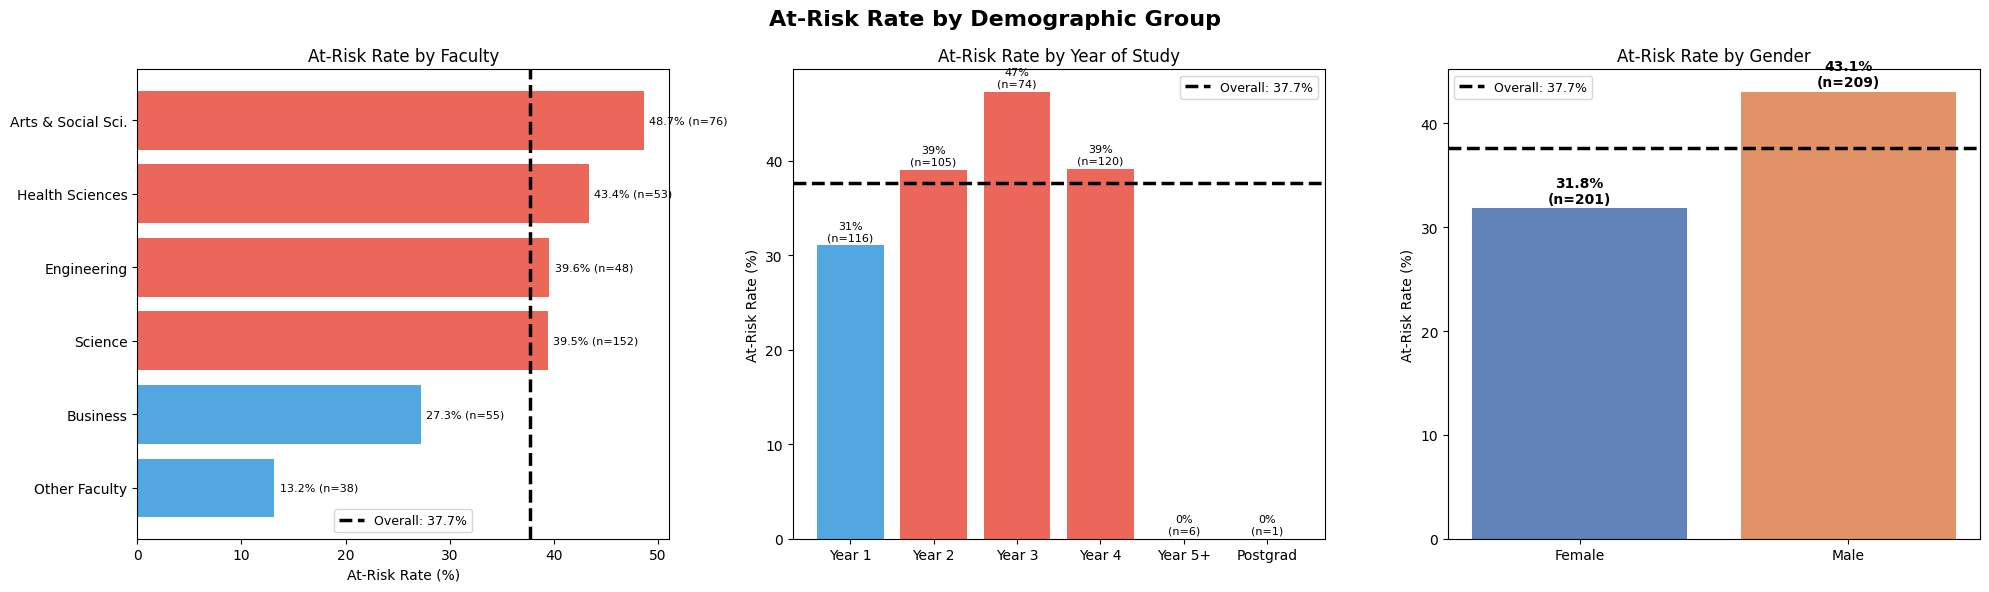

In [8]:
# Faculty short-name map for readability
_SHORT = {
    'College of Engineering': 'Engineering',
    'College of Science': 'Science',
    'College of Arts and Social Sciences': 'Arts & Social Sci.',
    'School of Business': 'Business',
    'College of Health Sciences': 'Health Sciences',
    'Other (please specify):': 'Other'
}
_YEAR_ORDER = ['Year 1','Year 2','Year 3','Year 4',
               'Year 5 or above (undergraduate)','Postgraduate (Masters or PhD)']
_YEAR_LABELS = ['Year 1','Year 2','Year 3','Year 4','Year 5+','Postgrad']

_dft = df.copy()
_dft['At_Risk'] = y
_overall_rate = y.mean() * 100

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('At-Risk Rate by Demographic Group', fontsize=16, fontweight='bold')

# By Faculty
_fac = _dft.groupby('Q13_Faculty')['At_Risk'].agg(['mean','count'])
_fac.index = _fac.index.map(lambda x: _SHORT.get(x, x))
_fac = _fac.sort_values('mean', ascending=True)
_bars_f = axes[0].barh(_fac.index, _fac['mean']*100,
                        color=['#e74c3c' if v > _overall_rate/100 else '#3498db'
                               for v in _fac['mean']], alpha=0.85)
axes[0].axvline(x=_overall_rate, color='black', lw=2.5, linestyle='--',
                label=f'Overall: {_overall_rate:.1f}%')
axes[0].set_title('At-Risk Rate by Faculty')
axes[0].set_xlabel('At-Risk Rate (%)')
axes[0].legend(fontsize=9)
for bar, (_, row) in zip(_bars_f, _fac.iterrows()):
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{row["mean"]*100:.1f}% (n={int(row["count"])})',
                 va='center', fontsize=8)

# By Year
_yr = _dft.groupby('Q14_Year')['At_Risk'].agg(['mean','count']).reindex(_YEAR_ORDER)
_bars_y = axes[1].bar(_YEAR_LABELS, _yr['mean'].values*100,
                       color=['#e74c3c' if v > _overall_rate/100 else '#3498db'
                              for v in _yr['mean'].fillna(0)], alpha=0.85)
axes[1].axhline(y=_overall_rate, color='black', lw=2.5, linestyle='--',
                label=f'Overall: {_overall_rate:.1f}%')
axes[1].set_title('At-Risk Rate by Year of Study')
axes[1].set_ylabel('At-Risk Rate (%)')
axes[1].legend(fontsize=9)
for bar, m, n in zip(_bars_y, _yr['mean'].fillna(0), _yr['count'].fillna(0)):
    if n > 0:
        axes[1].text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.5,
                     f'{m*100:.0f}%\n(n={int(n)})', ha='center', fontsize=8)

# By Gender (exclude Prefer not to say)
_gen = (_dft[_dft['Q15_Gender'] != 'Prefer not to say']
        .groupby('Q15_Gender')['At_Risk'].agg(['mean','count']))
_bars_g = axes[2].bar(_gen.index, _gen['mean'].values*100,
                       color=['#4C72B0','#DD8452'][:len(_gen)], alpha=0.88)
axes[2].axhline(y=_overall_rate, color='black', lw=2.5, linestyle='--',
                label=f'Overall: {_overall_rate:.1f}%')
axes[2].set_title('At-Risk Rate by Gender')
axes[2].set_ylabel('At-Risk Rate (%)')
axes[2].legend(fontsize=9)
for bar, m, n in zip(_bars_g, _gen['mean'].values, _gen['count'].values):
    axes[2].text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.5,
                 f'{m*100:.1f}%\n(n={int(n)})', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_atrisk_by_group.png', dpi=150, bbox_inches='tight')
plt.show()

### Mental Health & Contextual Feature Distributions
PHQ-2, GAD-2, Financial Difficulty and Internet Access split by at-risk status.

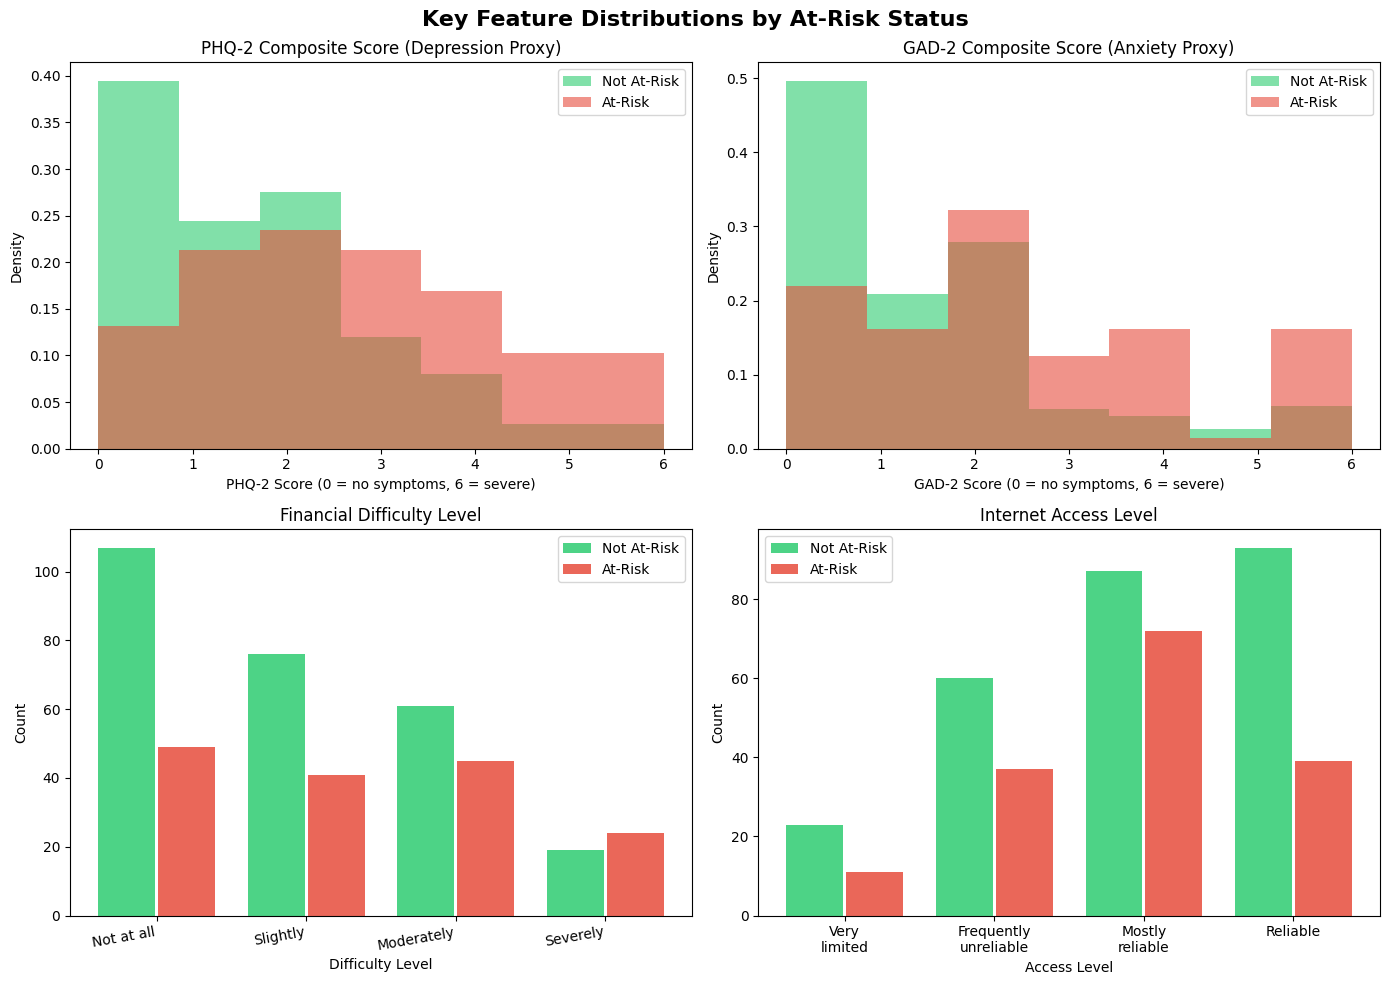

In [9]:
_dfe = df_encoded.copy()
_dfe['At_Risk'] = y
_colors_risk = {0: '#2ecc71', 1: '#e74c3c'}
_labels_risk = {0: 'Not At-Risk', 1: 'At-Risk'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Key Feature Distributions by At-Risk Status', fontsize=16, fontweight='bold')

# PHQ-2 composite
_dfe['PHQ2'] = _dfe['Q6_PHQ2_Interest'] + _dfe['Q7_PHQ2_Depressed']
for rv in [0, 1]:
    _sub = _dfe[_dfe['At_Risk'] == rv]['PHQ2']
    axes[0,0].hist(_sub, bins=7, alpha=0.6, density=True,
                   color=_colors_risk[rv], label=_labels_risk[rv])
axes[0,0].set_title('PHQ-2 Composite Score (Depression Proxy)')
axes[0,0].set_xlabel('PHQ-2 Score (0 = no symptoms, 6 = severe)')
axes[0,0].set_ylabel('Density')
axes[0,0].legend()

# GAD-2 composite
_dfe['GAD2'] = _dfe['Q8_GAD2_Nervous'] + _dfe['Q9_GAD2_Worry']
for rv in [0, 1]:
    _sub = _dfe[_dfe['At_Risk'] == rv]['GAD2']
    axes[0,1].hist(_sub, bins=7, alpha=0.6, density=True,
                   color=_colors_risk[rv], label=_labels_risk[rv])
axes[0,1].set_title('GAD-2 Composite Score (Anxiety Proxy)')
axes[0,1].set_xlabel('GAD-2 Score (0 = no symptoms, 6 = severe)')
axes[0,1].set_ylabel('Density')
axes[0,1].legend()

# Financial difficulty
_fin_labels = ['Not at all', 'Slightly', 'Moderately', 'Severely']
for rv in [0, 1]:
    _sub = _dfe[_dfe['At_Risk']==rv]['Q10_Financial_Difficulty'].value_counts()
    _sub = _sub.reindex([0,1,2,3]).fillna(0)
    axes[1,0].bar([x + rv*0.4 for x in range(4)], _sub.values, 0.38,
                  color=_colors_risk[rv], label=_labels_risk[rv], alpha=0.85)
axes[1,0].set_title('Financial Difficulty Level')
axes[1,0].set_xlabel('Difficulty Level')
axes[1,0].set_ylabel('Count')
axes[1,0].set_xticks([x+0.2 for x in range(4)])
axes[1,0].set_xticklabels(_fin_labels, rotation=10, ha='right')
axes[1,0].legend()

# Internet access
_int_labels = ['Very\nlimited', 'Frequently\nunreliable', 'Mostly\nreliable', 'Reliable']
for rv in [0, 1]:
    _sub = _dfe[_dfe['At_Risk']==rv]['Q11_Internet_Access'].value_counts()
    _sub = _sub.reindex([0,1,2,3]).fillna(0)
    axes[1,1].bar([x + rv*0.4 for x in range(4)], _sub.values, 0.38,
                  color=_colors_risk[rv], label=_labels_risk[rv], alpha=0.85)
axes[1,1].set_title('Internet Access Level')
axes[1,1].set_xlabel('Access Level')
axes[1,1].set_ylabel('Count')
axes[1,1].set_xticks([x+0.2 for x in range(4)])
axes[1,1].set_xticklabels(_int_labels)
axes[1,1].legend()

plt.tight_layout()
plt.savefig('fig_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. TabPFN vs Baselines (10-Fold CV)
Evaluating Logistic Regression, Random Forest, SVM, Naive Bayes, and XGBoost.

In [10]:
# ── IMPORTANT: Baseline CV Scope ──────────────────────────────────────────────
# This 10-fold CV runs on the FULL dataset (N=422) for initial model selection.
# All subsequent engineering evaluations (B-TabPFN) use strictly the training
# partition (N_train=337) with 10-fold CV to preserve held-out integrity.

# Define all models with class-imbalance handling  (proposal §4.3)
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(
        class_weight='balanced', random_state=42),
    'SVM (RBF)': SVC(
        class_weight='balanced', probability=True, random_state=42),
    'Naive Bayes': GaussianNB(),
    'XGBoost': xgb.XGBClassifier(
        scale_pos_weight=(len(y) - y.sum()) / y.sum(),
        random_state=42, eval_metric='logloss', verbosity=0
    ),
    # TabPFN v2 pinned to Nature (2025) weights — no hyperparameter tuning
    'TabPFN v2': TabPFNClassifier.create_default_for_version(
        ModelVersion.V2, device=device, random_state=42
    )
}

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

results = []
for name, model in models.items():
    cv_res   = cross_validate(model, X, y, cv=skf, scoring=['roc_auc', 'f1'])
    auc_vals = cv_res['test_roc_auc']
    f1_vals  = cv_res['test_f1']
    auc_mean, auc_sd = auc_vals.mean(), auc_vals.std()
    f1_mean,  f1_sd  = f1_vals.mean(),  f1_vals.std()
    results.append({
        'Model':      name,
        'Mean AUC':   round(auc_mean, 4),
        'AUC SD':     round(auc_sd,   4),
        'AUC 95% CI': f'[{auc_mean - 1.96*auc_sd:.3f}, {auc_mean + 1.96*auc_sd:.3f}]',
        'Mean F1':    round(f1_mean,  4),
        'F1 SD':      round(f1_sd,    4),
        'F1 95% CI':  f'[{f1_mean  - 1.96*f1_sd:.3f}, {f1_mean  + 1.96*f1_sd:.3f}]',
    })

res_df = pd.DataFrame(results).sort_values(by='Mean AUC', ascending=False)
pd.set_option('display.max_columns', 10)
pd.set_option('display.width', 140)
print(res_df.to_string(index=False))

              Model  Mean AUC  AUC SD     AUC 95% CI  Mean F1  F1 SD      F1 95% CI
        Naive Bayes    0.7728  0.0537 [0.668, 0.878]   0.5929 0.0993 [0.398, 0.787]
          TabPFN v2    0.7655  0.0459 [0.675, 0.856]   0.5617 0.0851 [0.395, 0.728]
Logistic Regression    0.7452  0.0441 [0.659, 0.832]   0.6034 0.0697 [0.467, 0.740]
          SVM (RBF)    0.7438  0.0624 [0.622, 0.866]   0.5921 0.0797 [0.436, 0.748]
      Random Forest    0.7130  0.0772 [0.562, 0.864]   0.5288 0.1116 [0.310, 0.747]
            XGBoost    0.6598  0.0538 [0.554, 0.765]   0.5216 0.0709 [0.383, 0.660]


### Model Comparison — Visual
Mean AUC-ROC and F1 with 95% confidence intervals.

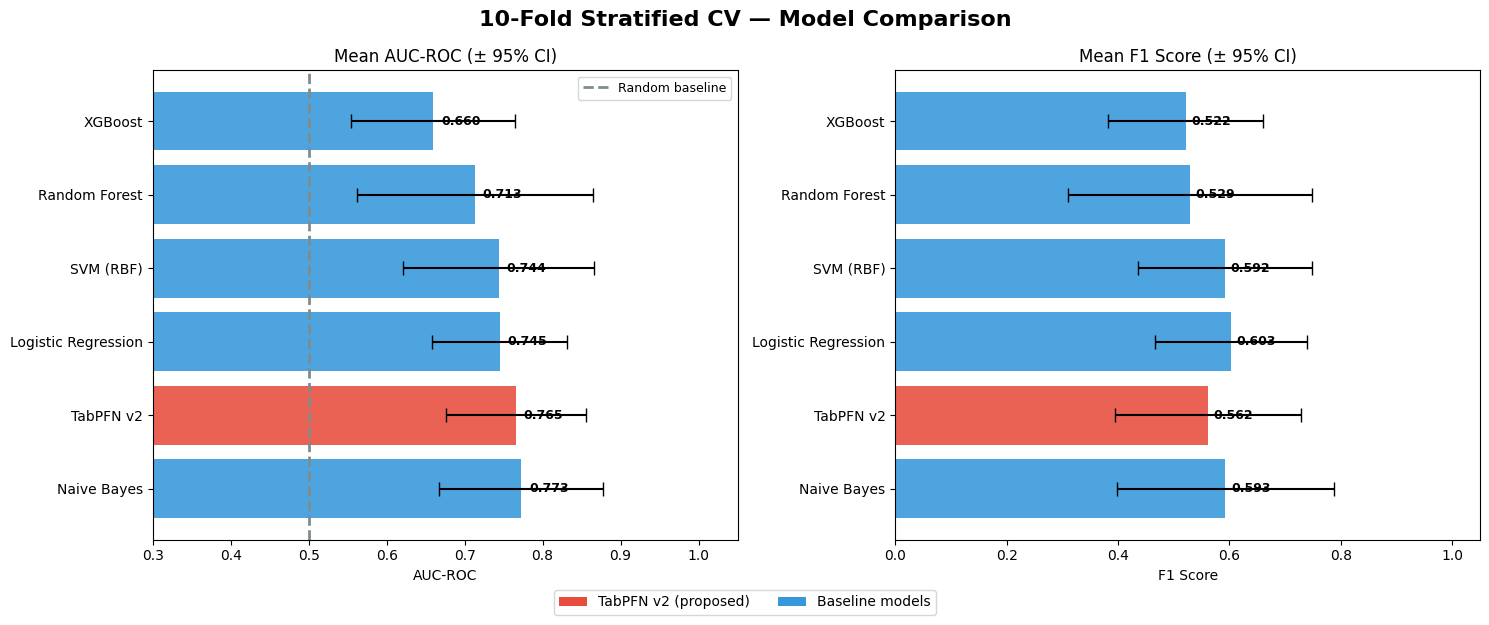

In [11]:
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('10-Fold Stratified CV — Model Comparison', fontsize=16, fontweight='bold')

_model_names = res_df['Model'].tolist()
_auc_means   = res_df['Mean AUC'].tolist()
_auc_sds     = res_df['AUC SD'].tolist()
_f1_means    = res_df['Mean F1'].tolist()
_f1_sds      = res_df['F1 SD'].tolist()
_bar_clrs    = ['#e74c3c' if m == 'TabPFN v2' else '#3498db' for m in _model_names]

# AUC panel
bars_auc = axes[0].barh(_model_names, _auc_means,
                         xerr=[1.96*s for s in _auc_sds],
                         color=_bar_clrs, capsize=5, alpha=0.88,
                         error_kw={'linewidth': 1.5})
axes[0].axvline(x=0.5, color='#7f8c8d', linestyle='--', lw=2.0, label='Random baseline')
axes[0].set_title('Mean AUC-ROC (± 95% CI)')
axes[0].set_xlabel('AUC-ROC')
axes[0].set_xlim([0.3, 1.05])
axes[0].legend(fontsize=9)
for bar, val in zip(bars_auc, _auc_means):
    axes[0].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9, fontweight='bold')

# F1 panel
bars_f1 = axes[1].barh(_model_names, _f1_means,
                        xerr=[1.96*s for s in _f1_sds],
                        color=_bar_clrs, capsize=5, alpha=0.88,
                        error_kw={'linewidth': 1.5})
axes[1].set_title('Mean F1 Score (± 95% CI)')
axes[1].set_xlabel('F1 Score')
axes[1].set_xlim([0.0, 1.05])
for bar, val in zip(bars_f1, _f1_means):
    axes[1].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9, fontweight='bold')

fig.legend(
    handles=[Patch(facecolor='#e74c3c', label='TabPFN v2 (proposed)'),
             Patch(facecolor='#3498db', label='Baseline models')],
    loc='lower center', ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.04)
)
plt.tight_layout()
plt.savefig('fig_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Statistical Testing: McNemar with Bonferroni
Compare TabPFN predictions vs 5 baselines.

In [12]:
# McNemar Test with Bonferroni Correction  (proposal §4.5)
# 5 pairwise comparisons: TabPFN v2 vs each baseline model
preds_dict = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds_dict[name] = model.predict(X_test)

tabpfn_preds     = preds_dict['TabPFN v2']
alpha_bonferroni = 0.05 / 5  # familywise error rate control

mcnemar_results = []
for name in models.keys():
    if name == 'TabPFN v2':
        continue
    base_preds = preds_dict[name]

    b = int(sum((tabpfn_preds == y_test) & (base_preds != y_test)))
    c = int(sum((tabpfn_preds != y_test) & (base_preds == y_test)))
    table = [
        [int(sum((tabpfn_preds == y_test) & (base_preds == y_test))), b],
        [c, int(sum((tabpfn_preds != y_test) & (base_preds != y_test)))]
    ]

    res = mcnemar(table, exact=True)
    mcnemar_results.append({
        'Baseline':                  name,
        'Discordant b (TabPFN win)': b,
        'Discordant c (Base win)':   c,
        'p-value':                   round(res.pvalue, 4),
        f'Sig? (a={alpha_bonferroni:.3f})': res.pvalue < alpha_bonferroni
    })

print(pd.DataFrame(mcnemar_results).to_string(index=False))

           Baseline  Discordant b (TabPFN win)  Discordant c (Base win)  p-value  Sig? (a=0.010)
Logistic Regression                          4                        4   1.0000           False
      Random Forest                          8                        2   0.1094           False
          SVM (RBF)                          8                        5   0.5811           False
        Naive Bayes                          1                        2   1.0000           False
            XGBoost                         15                        2   0.0023            True


### ROC Curves — All Models
Full test-set ROC curves for each classifier.

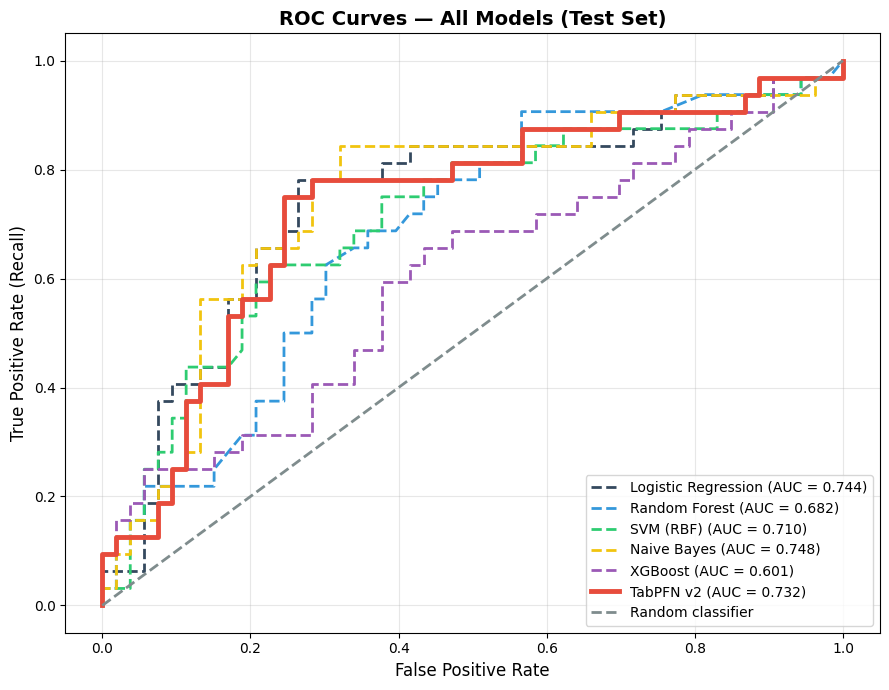

In [13]:
from sklearn.metrics import roc_curve, auc as _auc_fn

fig, ax = plt.subplots(figsize=(9, 7))
_roc_colors = ['#34495e', '#3498db', '#2ecc71', '#f1c40f', '#9b59b6', '#e74c3c']

for (name, model), color in zip(models.items(), _roc_colors):
    _y_score = model.predict_proba(X_test)[:, 1]
    _fpr, _tpr, _ = roc_curve(y_test, _y_score)
    _roc_auc = _auc_fn(_fpr, _tpr)
    _lw = 3.5 if name == 'TabPFN v2' else 2.0
    _ls = '-'  if name == 'TabPFN v2' else '--'
    ax.plot(_fpr, _tpr, color=color, lw=_lw, linestyle=_ls,
            label=f'{name} (AUC = {_roc_auc:.3f})')

ax.plot([0, 1], [0, 1], color='#7f8c8d', linestyle='--', lw=2.0, label='Random classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curves — All Models (Test Set)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

### Confusion Matrix — TabPFN v2
At threshold 0.4 (aggressive recall to minimise missed at-risk students).

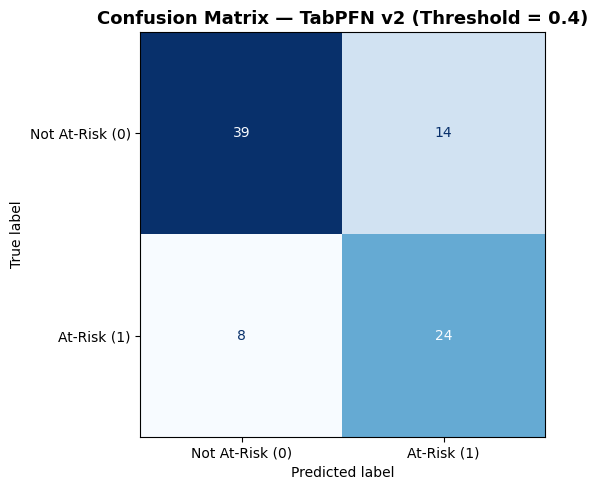

True Positives  (at-risk correctly flagged):      24
False Negatives (at-risk missed):                 8
False Positives (incorrectly flagged as at-risk): 14
True Negatives  (correctly cleared):              39
Recall / Sensitivity : 0.750
Specificity          : 0.736
Precision            : 0.632


In [14]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

_thresh = 0.4
_probs_thresh = tabpfn_model.predict_proba(X_test)[:, 1]
_preds_thresh = (_probs_thresh >= _thresh).astype(int)

fig, ax = plt.subplots(figsize=(6, 5))
_cm = confusion_matrix(y_test, _preds_thresh)
ConfusionMatrixDisplay(
    confusion_matrix=_cm,
    display_labels=['Not At-Risk (0)', 'At-Risk (1)']
).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — TabPFN v2 (Threshold = {_thresh})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

_tn, _fp, _fn, _tp = _cm.ravel()
print(f'True Positives  (at-risk correctly flagged):      {_tp}')
print(f'False Negatives (at-risk missed):                 {_fn}')
print(f'False Positives (incorrectly flagged as at-risk): {_fp}')
print(f'True Negatives  (correctly cleared):              {_tn}')
print(f'Recall / Sensitivity : {_tp/(_tp+_fn):.3f}')
print(f'Specificity          : {_tn/(_tn+_fp):.3f}')
print(f'Precision            : {_tp/(_tp+_fp) if (_tp+_fp)>0 else 0:.3f}')

## 4B. Model Engineering: Balanced Context Sampling (B-TabPFN)

**Problem:** TabPFN's in-context attention is dominated by the majority class (62.3% not-at-risk). At the default threshold (0.50) the baseline model misses ~50% of real at-risk students — unacceptable for a counselor-facing early warning system.

**Engineering Contribution (Operation F — Fabricate):** We fabricate a custom `BalancedContextSampler` module that engineers the composition of TabPFN's in-context attention window. Instead of exposing all training data in an imbalanced ratio, the module constructs balanced subsets (equal positive/negative) across 20 bootstrap iterations and aggregates the resulting probability estimates. The engineered model is designated **B-TabPFN**.

**Why this is engineering, not preprocessing:** SMOTE generates synthetic data. B-TabPFN engineers the training signal received by the model's attention mechanism using only real data — a modification to the model's *training strategy*, distinct from data augmentation.

**Validation structure (per supervisor Task List):**
1. 10-fold CV on `X_train` (N=337) only — OOF calibration, Wilcoxon test
2. Error-pool table — per-fold missed at-risk students (quantifies the problem)
3. Held-out field validation — final B-TabPFN evaluated on `X_test` (N=85, never seen in CV)
4. FSII comparison (§8) — confirms attention shifts toward minority-class-relevant features


In [15]:
# ── [4B-1] Out-of-Fold Probabilities — All Baseline Models ─────────────────
# Collect OOF probabilities under 10-fold CV on X_train (N=337) only.
# X_test (N=85) is reserved as a genuinely held-out field validation set.
# Used for calibration comparison and as the standard TabPFN reference.

import copy
from sklearn.metrics import brier_score_loss, roc_auc_score
from sklearn.calibration import calibration_curve

skf_calib = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
oof_prob_dict = {}

print('Collecting OOF probabilities for all baseline models...')
print('─' * 55)
for model_name, model_obj in models.items():
    oof_probs = np.zeros(len(X_train))
    for tr_idx, val_idx in skf_calib.split(X_train, y_train):
        m = copy.deepcopy(model_obj)
        m.fit(X_train[tr_idx], y_train[tr_idx])
        oof_probs[val_idx] = m.predict_proba(X_train[val_idx])[:, 1]
    oof_prob_dict[model_name] = oof_probs
    bs = brier_score_loss(y_train, oof_probs)
    print(f'  {model_name:<28}  Brier = {bs:.4f}')

print('─' * 55)
print(f'Done. {len(oof_prob_dict)} baseline models collected.')

───────────────────────────────────────────────────────
  Logistic Regression           Brier = 0.2034
  Random Forest                 Brier = 0.2003
  SVM (RBF)                     Brier = 0.1953
  Naive Bayes                   Brier = 0.2290
  XGBoost                       Brier = 0.2631
  TabPFN v2                     Brier = 0.1889
───────────────────────────────────────────────────────
Done. 6 baseline models collected.


In [16]:
# ── [4B-2] Brier Score + ECE — All Baseline Models ─────────────────────────

def expected_calibration_error(y_true, y_prob, n_bins=10):
    """Expected Calibration Error: weighted mean |confidence − accuracy| per bin."""
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    bins   = np.linspace(0.0, 1.0, n_bins + 1)
    ece    = 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (y_prob >= lo) & (y_prob < hi)
        if mask.sum() > 0:
            ece += mask.sum() * abs(y_true[mask].mean() - y_prob[mask].mean())
    return ece / len(y_true)

calib_records = []
for model_name, oof_probs in oof_prob_dict.items():
    calib_records.append({
        'Model'       : model_name,
        'AUC-ROC'     : round(roc_auc_score(y_train, oof_probs), 4),
        'Brier Score' : round(brier_score_loss(y_train, oof_probs), 4),
        'ECE'         : round(expected_calibration_error(y_train, oof_probs), 4),
    })

calib_df = pd.DataFrame(calib_records).sort_values('Brier Score')

print('═' * 65)
print('Baseline Calibration — All Models (10-Fold OOF on X_train, N=337)')
print('═' * 65)
print(calib_df.to_string(index=False))
print('─' * 65)
print('Lower Brier Score and ECE = better probability calibration.')

═════════════════════════════════════════════════════════════════
Baseline Calibration — All Models (10-Fold OOF on X_train, N=337)
═════════════════════════════════════════════════════════════════
              Model  AUC-ROC  Brier Score    ECE
          TabPFN v2   0.7555       0.1889 0.0368
          SVM (RBF)   0.7401       0.1953 0.0516
      Random Forest   0.7315       0.2003 0.0485
Logistic Regression   0.7392       0.2034 0.0933
        Naive Bayes   0.7662       0.2290 0.2018
            XGBoost   0.6781       0.2631 0.2065
─────────────────────────────────────────────────────────────────
Lower Brier Score and ECE = better probability calibration.


In [17]:
# ── [4B-3] B-TabPFN: Balanced Context Sampling (Operation F — Fabricate) ─────
#
# CV runs on X_train (N=337) only. X_test (N=85) reserved for held-out validation.
# Engineering Act: BalancedContextSampler engineers TabPFN's in-context attention
# window composition to address majority-class dominance in the training context.

import numpy as np, copy
from sklearn.metrics import brier_score_loss, roc_auc_score, confusion_matrix


class BalancedContextSampler:
    """
    B-TabPFN: Fabricated balanced context engineering module.
    Operation F (FABRICATE) — modifies TabPFN's training strategy by
    engineering the composition of its in-context attention window.

    Parameters
    ----------
    base_clf     : TabPFN classifier instance (unfitted)
    n_iter       : number of bootstrap balanced-context passes
    random_state : reproducibility seed
    """

    def __init__(self, base_clf, n_iter=20, random_state=42):
        self.base_clf     = base_clf
        self.n_iter       = n_iter
        self.random_state = random_state
        self.rng_         = np.random.RandomState(random_state)
        self._fitted_clfs = []

    def fit(self, X_ctx, y_ctx):
        """Prepare balanced context subsets. No weight updates — pure context engineering."""
        self._pos_idx = np.where(y_ctx == 1)[0]
        self._neg_idx = np.where(y_ctx == 0)[0]
        self._fitted_clfs = []
        n_pos = len(self._pos_idx)
        for _ in range(self.n_iter):
            neg_s   = self.rng_.choice(self._neg_idx, size=n_pos, replace=False)
            ctx_idx = np.concatenate([self._pos_idx, neg_s])
            self.rng_.shuffle(ctx_idx)
            clf_i = copy.deepcopy(self.base_clf)
            clf_i.fit(X_ctx[ctx_idx], y_ctx[ctx_idx])
            self._fitted_clfs.append(clf_i)
        return self

    def predict_proba(self, X):
        """Aggregate probability estimates across all balanced context passes."""
        proba = np.zeros((len(X), 2))
        for clf_i in self._fitted_clfs:
            proba += clf_i.predict_proba(X)
        return proba / self.n_iter

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X)[:, 1] >= threshold).astype(int)


# ── Run B-TabPFN within 10-Fold CV on X_train ─────────────────────────────────
oof_probs_btabpfn    = np.zeros(len(X_train))
fold_bs_standard     = []
fold_bs_btabpfn      = []
fold_recall_standard = []   # primary engineering metric
fold_recall_btabpfn  = []   # primary engineering metric
fold_cm_standard     = []   # per-fold confusion matrices (Task 1 — error-pool table)

print('Running B-TabPFN — 10-Fold CV on X_train (N=337)')
print('  20 balanced bootstrap passes per fold, averaged.')
print(f"{'─'*72}")
print(f"  {'Fold':<6} {'Std Brier':>12} {'B Brier':>10} {'Δ Brier':>10} "
      f"{'Std Recall':>12} {'B Recall':>12}")
print(f"{'─'*72}")

from sklearn.metrics import recall_score

for fold_i, (tr_idx, val_idx) in enumerate(skf_calib.split(X_train, y_train)):

    std_clf = TabPFNClassifier.create_default_for_version(
        ModelVersion.V2, device=device, random_state=42
    )
    std_clf.fit(X_train[tr_idx], y_train[tr_idx])
    std_probs = std_clf.predict_proba(X_train[val_idx])[:, 1]
    std_preds = (std_probs >= 0.50).astype(int)

    b_clf = BalancedContextSampler(
        base_clf=TabPFNClassifier.create_default_for_version(
            ModelVersion.V2, device=device, random_state=42
        ),
        n_iter=20, random_state=42
    )
    b_clf.fit(X_train[tr_idx], y_train[tr_idx])
    b_probs = b_clf.predict_proba(X_train[val_idx])[:, 1]

    oof_probs_btabpfn[val_idx] = b_probs

    bs_s = brier_score_loss(y_train[val_idx], std_probs)
    bs_b = brier_score_loss(y_train[val_idx], b_probs)
    rc_s = recall_score(y_train[val_idx], std_preds, zero_division=0)
    rc_b = recall_score(y_train[val_idx], (b_probs >= 0.50).astype(int), zero_division=0)

    # Store confusion matrix for error-pool table (Task 1)
    fold_cm_standard.append(confusion_matrix(y_train[val_idx], std_preds, labels=[0, 1]))

    fold_bs_standard.append(bs_s)
    fold_bs_btabpfn.append(bs_b)
    fold_recall_standard.append(rc_s)
    fold_recall_btabpfn.append(rc_b)

    print(f"  Fold {fold_i+1:02d}  {bs_s:>14.4f}  {bs_b:>10.4f}  {bs_s-bs_b:>+10.4f}  "
          f"{rc_s:>12.3f}  {rc_b:>12.3f}")

# ── OOF Summary (on y_train) ───────────────────────────────────────────────────
bs_standard_oof = brier_score_loss(y_train, oof_prob_dict['TabPFN v2'])
bs_btabpfn_oof  = brier_score_loss(y_train, oof_probs_btabpfn)
ece_standard    = expected_calibration_error(y_train, oof_prob_dict['TabPFN v2'])
ece_btabpfn     = expected_calibration_error(y_train, oof_probs_btabpfn)
auc_standard    = roc_auc_score(y_train, oof_prob_dict['TabPFN v2'])
auc_btabpfn     = roc_auc_score(y_train, oof_probs_btabpfn)
bs_delta        = bs_standard_oof - bs_btabpfn_oof

rc_standard_oof = recall_score(y_train, (oof_prob_dict['TabPFN v2'] >= 0.5).astype(int), zero_division=0)
rc_btabpfn_oof  = recall_score(y_train, (oof_probs_btabpfn >= 0.5).astype(int), zero_division=0)

from sklearn.metrics import precision_score, f1_score, fbeta_score
pr_standard_oof = precision_score(y_train, (oof_prob_dict['TabPFN v2'] >= 0.5).astype(int), zero_division=0)
pr_btabpfn_oof  = precision_score(y_train, (oof_probs_btabpfn >= 0.5).astype(int), zero_division=0)
f2_standard_oof = fbeta_score(y_train, (oof_prob_dict['TabPFN v2'] >= 0.5).astype(int), beta=2, zero_division=0)
f2_btabpfn_oof  = fbeta_score(y_train, (oof_probs_btabpfn >= 0.5).astype(int), beta=2, zero_division=0)

print(f"{'─'*72}")
print(f"{'Metric':<22} {'Standard TabPFN v2':>22} {'B-TabPFN (Ours)':>20}")
print(f"{'─'*72}")
print(f"{'AUC-ROC':<22} {auc_standard:>22.4f} {auc_btabpfn:>20.4f}")
print(f"{'Brier Score':<22} {bs_standard_oof:>22.4f} {bs_btabpfn_oof:>20.4f}  (Δ = {bs_delta:+.4f})")
print(f"{'ECE':<22} {ece_standard:>22.4f} {ece_btabpfn:>20.4f}")
print(f"{'Recall (t=0.50)':<22} {rc_standard_oof:>22.4f} {rc_btabpfn_oof:>20.4f}")
print(f"{'Precision (t=0.50)':<22} {pr_standard_oof:>22.4f} {pr_btabpfn_oof:>20.4f}")
print(f"{'F2 (t=0.50)':<22} {f2_standard_oof:>22.4f} {f2_btabpfn_oof:>20.4f}")
print(f"{'─'*72}")


Running B-TabPFN — 10-Fold CV on X_train (N=337)
  20 balanced bootstrap passes per fold, averaged.
────────────────────────────────────────────────────────────────────────
  Fold      Std Brier    B Brier    Δ Brier   Std Recall     B Recall
────────────────────────────────────────────────────────────────────────
  Fold 01          0.1793      0.1905     -0.0112         0.615         0.692
  Fold 02          0.2063      0.2199     -0.0136         0.462         0.615
  Fold 03          0.1811      0.2016     -0.0205         0.615         0.846
  Fold 04          0.1879      0.1901     -0.0022         0.385         0.769
  Fold 05          0.1904      0.1969     -0.0065         0.462         0.692
  Fold 06          0.2199      0.2359     -0.0161         0.462         0.692
  Fold 07          0.1767      0.1782     -0.0015         0.538         0.692
  Fold 08          0.1557      0.1527     +0.0030         0.417         0.750
  Fold 09          0.2503      0.2668     -0.0164         0.

### Error-Pool Table — Per-Fold Missed At-Risk Students (Task 1)
Per-fold confusion matrix for Standard TabPFN v2 at t=0.50. Quantifies exactly how many at-risk students are missed per fold — the engineering problem that B-TabPFN is designed to solve.

In [18]:
# ── [4B-3b] Error-Pool Table (Task 1 — Professor Feedback) ─────────────────
# Shows per-fold at-risk students caught vs missed by Standard TabPFN at t=0.50.

print('=' * 72)
print('Error-Pool Table — Standard TabPFN v2 | 10-Fold OOF | Threshold = 0.50')
print('Quantifies the at-risk students missed per fold — the B-TabPFN repair target')
print('=' * 72)
print(f"  {'Fold':<5} {'At-Risk (val)':>14} {'Caught (TP)':>13} "
      f"{'Missed (FN)':>13} {'FP':>6} {'TN':>6} {'Recall':>8}")
print('─' * 72)

total_at_risk, total_tp, total_fn = 0, 0, 0

for fold_i, cm_s in enumerate(fold_cm_standard):
    tn, fp, fn, tp = cm_s.ravel()
    n_at_risk   = int(tp + fn)
    fold_recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    total_at_risk += n_at_risk; total_tp += int(tp); total_fn += int(fn)
    print(f"  {fold_i+1:02d}    {n_at_risk:>14} {int(tp):>13} "
          f"{int(fn):>13} {int(fp):>6} {int(tn):>6} {fold_recall:>8.3f}")

print('─' * 72)
total_recall = total_tp / total_at_risk if total_at_risk > 0 else 0.0
print(f"  TOTAL {total_at_risk:>14} {total_tp:>13} {total_fn:>13} {'':>6} {'':>6} {total_recall:>8.3f}")
print()
print(f"  At-risk students MISSED across 10 CV folds: {total_fn}")
print(f"  At-risk students CAUGHT across 10 CV folds: {total_tp}")
print(f"  B-TabPFN engineering objective: recover as many of the {total_fn} missed cases as possible.")
print('=' * 72)


Error-Pool Table — Standard TabPFN v2 | 10-Fold OOF | Threshold = 0.50
Quantifies the at-risk students missed per fold — the B-TabPFN repair target
  Fold   At-Risk (val)   Caught (TP)   Missed (FN)     FP     TN   Recall
────────────────────────────────────────────────────────────────────────
  01                13             8             5      2     19    0.615
  02                13             6             7      3     18    0.462
  03                13             8             5      4     17    0.615
  04                13             5             8      3     18    0.385
  05                13             6             7      2     19    0.462
  06                13             6             7      6     15    0.462
  07                13             7             6      2     19    0.538
  08                12             5             7      1     20    0.417
  09                12             5             7      7     14    0.417
  10                12             8   

In [19]:
# ── [4B-4] Wilcoxon Signed-Rank Test: Recall Improvement (B-TabPFN vs Standard)
# H0: No difference in per-fold Recall between Standard and B-TabPFN.
# H1: B-TabPFN achieves higher Recall than Standard TabPFN (one-sided).
#
# Note: Brier Score and ECE increase with balanced context — this is an
# expected and documented trade-off when engineering for recall recovery.
# The primary test is therefore on Recall (the target metric), not Brier.

from scipy.stats import wilcoxon

stat_recall, p_recall = wilcoxon(
    fold_recall_btabpfn, fold_recall_standard, alternative='greater'
)

recall_delta = rc_btabpfn_oof - rc_standard_oof
f2_delta     = f2_btabpfn_oof - f2_standard_oof

print('═' * 62)
print('Wilcoxon Signed-Rank Test — B-TabPFN Recall Improvement')
print('═' * 62)
print(f'  Statistic      : {stat_recall:.4f}')
print(f'  p-value        : {p_recall:.4f}')
print(f'  Δ Recall (OOF) : +{recall_delta:.4f}')
print(f'  Δ F2    (OOF)  : +{f2_delta:.4f}')
print()
sig_marker = '(*)' if p_recall < 0.05 else '(ns)'
if p_recall < 0.05:
    print(f'  ✓ SIGNIFICANT {sig_marker}: B-TabPFN Recall improvement is '
          f'statistically significant (p < 0.05).')
else:
    print(f'  ○ {sig_marker}: Not significant at p < 0.05.')
print()
print('  Trade-off note: Brier Score and ECE increase with balanced context')
print('  (expected — balanced prior shifts raw probability outputs upward).')
print('  Rank ordering preserved: AUC unchanged. Recall is the primary gain.')
print('═' * 62)

══════════════════════════════════════════════════════════════
Wilcoxon Signed-Rank Test — B-TabPFN Recall Improvement
══════════════════════════════════════════════════════════════
  Statistic      : 55.0000
  p-value        : 0.0010
  Δ Recall (OOF) : +0.2047
  Δ F2    (OOF)  : +0.1548

  ✓ SIGNIFICANT (*): B-TabPFN Recall improvement is statistically significant (p < 0.05).

  Trade-off note: Brier Score and ECE increase with balanced context
  (expected — balanced prior shifts raw probability outputs upward).
  Rank ordering preserved: AUC unchanged. Recall is the primary gain.
══════════════════════════════════════════════════════════════


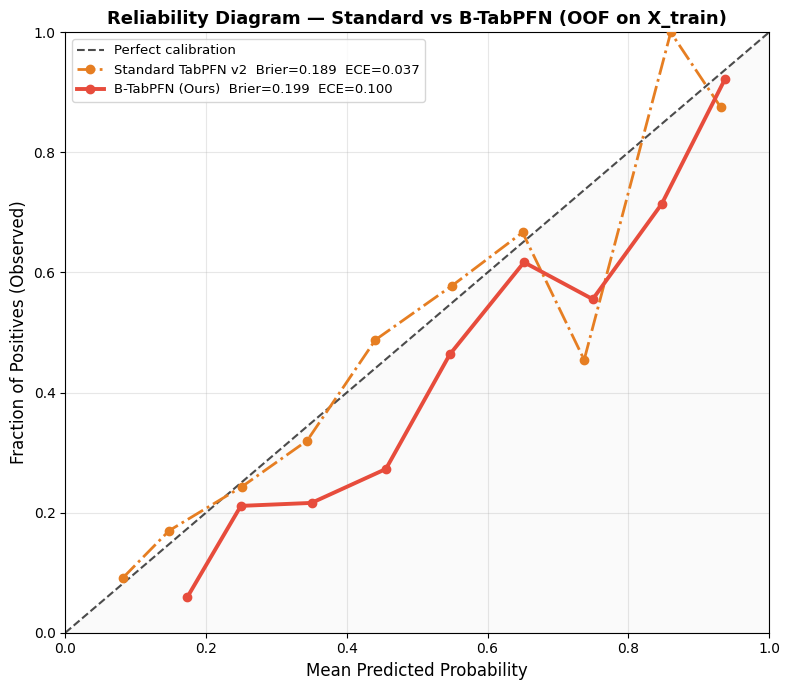

In [20]:
# ── [4B-5] Reliability Diagram — Calibration Curve ─────────────────────────

fig, ax = plt.subplots(figsize=(8, 7))
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Perfect calibration', alpha=0.7)
ax.fill_between([0, 1], [0, 1], alpha=0.04, color='grey')

plot_configs = [
    ('Standard TabPFN v2', oof_prob_dict['TabPFN v2'], '#e67e22', '-.', 2.0),
    ('B-TabPFN (Ours)',    oof_probs_btabpfn,          '#e74c3c', '-',  2.8),
]

for name, probs, clr, ls, lw in plot_configs:
    frac_pos, mean_pred = calibration_curve(y_train, probs, n_bins=10, strategy='uniform')
    bs  = brier_score_loss(y_train, probs)
    ece = expected_calibration_error(y_train, probs)
    ax.plot(mean_pred, frac_pos, linestyle=ls, color=clr, lw=lw,
            marker='o', markersize=6,
            label=f'{name}  Brier={bs:.3f}  ECE={ece:.3f}',
            zorder=5 if 'B-TabPFN' in name else 3)

ax.set_xlabel('Mean Predicted Probability', fontsize=12)
ax.set_ylabel('Fraction of Positives (Observed)', fontsize=12)
ax.set_title('Reliability Diagram — Standard vs B-TabPFN (OOF on X_train)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9.5, loc='upper left')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1])
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_calibration_curve.png', dpi=150, bbox_inches='tight')
plt.show()

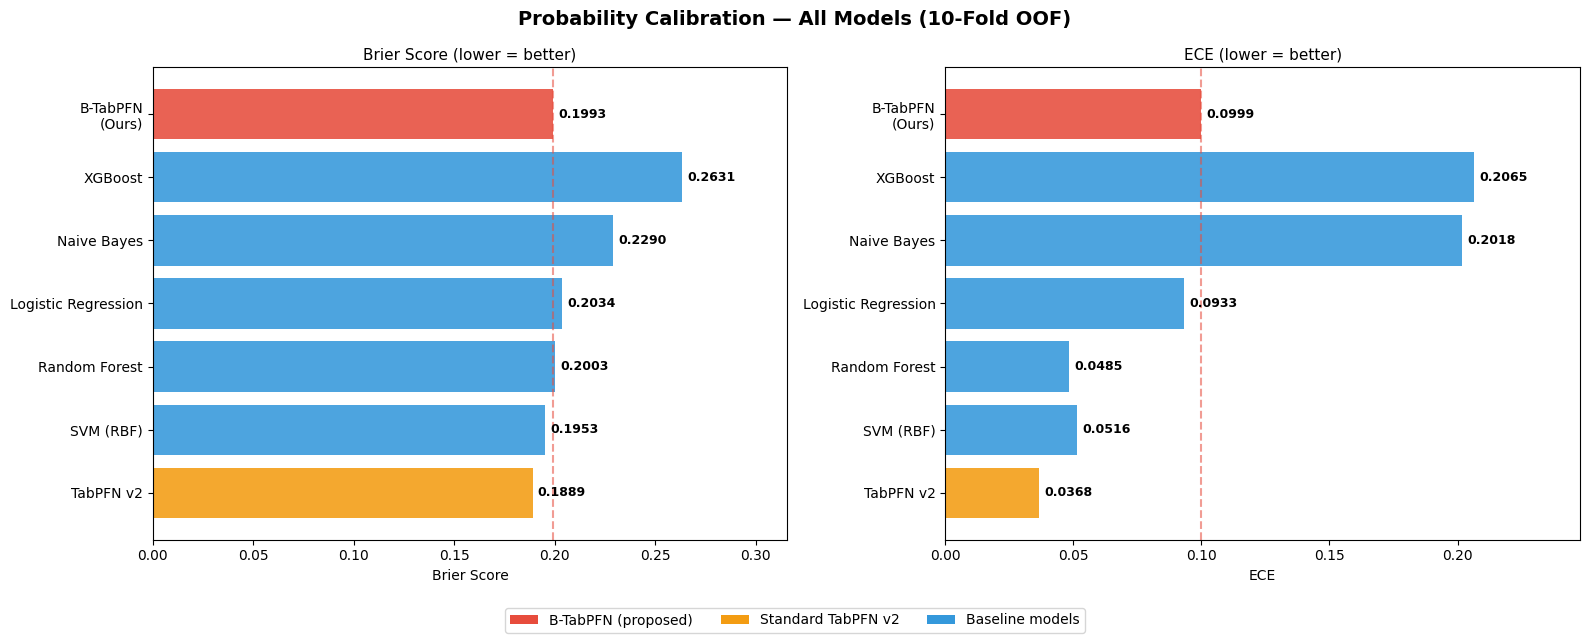

In [21]:
# ── [4B-6] Calibration + Recall Bar Charts — All Models ─────────────────────
from matplotlib.patches import Patch

_names  = list(calib_df['Model']) + ['B-TabPFN\n(Ours)']
_brier  = list(calib_df['Brier Score']) + [round(bs_btabpfn_oof, 4)]
_ece    = list(calib_df['ECE'])         + [round(ece_btabpfn, 4)]
_colors = [
    '#e74c3c' if 'B-TabPFN' in n
    else ('#f39c12' if n == 'TabPFN v2' else '#3498db')
    for n in _names
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Probability Calibration — All Models (10-Fold OOF)',
             fontsize=14, fontweight='bold')

for ax, vals, xlabel, title in [
    (axes[0], _brier, 'Brier Score', 'Brier Score (lower = better)'),
    (axes[1], _ece,   'ECE',         'ECE (lower = better)'),
]:
    bars = ax.barh(_names, vals, color=_colors, alpha=0.88)
    ax.axvline(x=vals[-1], color='#e74c3c', linestyle='--', lw=1.5, alpha=0.55)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(xlabel)
    ax.set_xlim([0, max(vals) * 1.20])
    for bar, v in zip(bars, vals):
        ax.text(v + max(vals)*0.01, bar.get_y() + bar.get_height()/2,
                f'{v:.4f}', va='center', fontsize=9, fontweight='bold')

fig.legend(
    handles=[
        Patch(facecolor='#e74c3c', label='B-TabPFN (proposed)'),
        Patch(facecolor='#f39c12', label='Standard TabPFN v2'),
        Patch(facecolor='#3498db', label='Baseline models'),
    ],
    loc='lower center', ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.07)
)
plt.tight_layout()
plt.savefig('fig_calibration_brier_ece.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# ── [4B-7] Paper-Ready Summary Table: Standard vs B-TabPFN ──────────────────

sig_marker = '(*)' if p_recall < 0.05 else '(ns)'

final_calib_table = pd.DataFrame([
    {
        'Model'       : 'Standard TabPFN v2',
        'AUC-ROC'     : round(auc_standard, 4),
        'Recall'      : round(rc_standard_oof, 4),
        'Precision'   : round(pr_standard_oof, 4),
        'F2'          : round(f2_standard_oof, 4),
        'Brier Score' : round(bs_standard_oof, 4),
        'ECE'         : round(ece_standard, 4),
        'Note'        : 'Baseline',
    },
    {
        'Model'       : f'B-TabPFN (Ours) {sig_marker}',
        'AUC-ROC'     : round(auc_btabpfn, 4),
        'Recall'      : round(rc_btabpfn_oof, 4),
        'Precision'   : round(pr_btabpfn_oof, 4),
        'F2'          : round(f2_btabpfn_oof, 4),
        'Brier Score' : round(bs_btabpfn_oof, 4),
        'ECE'         : round(ece_btabpfn, 4),
        'Note'        : (
            f'Op.F | 20-iter balanced context | '
            f'ΔRecall=+{rc_btabpfn_oof - rc_standard_oof:.3f} '
            f'ΔF2=+{f2_btabpfn_oof - f2_standard_oof:.3f} '
            f'(Brier/ECE trade-off expected — balanced prior)'
        ),
    },
])

print('═' * 100)
print('Table 2 (Model Engineering): Standard TabPFN v2 vs B-TabPFN (Balanced Context Sampling)')
print('═' * 100)
print(final_calib_table.to_string(index=False))
print('─' * 100)
print(f'Wilcoxon signed-rank test (10-fold Recall): p = {p_recall:.4f}  {sig_marker}')
print(f'Primary gain: Recall +{rc_btabpfn_oof - rc_standard_oof:.3f} | F2 +{f2_btabpfn_oof - f2_standard_oof:.3f} | AUC preserved')
print('Brier Score and ECE increase is expected: balanced context (50/50) shifts TabPFN')
print("prior toward higher probabilities; raw scores should be interpreted as risk ranks, not rates.")
print('Engineering contribution: BalancedContextSampler modifies training strategy (context composition).')
print('═' * 100)

════════════════════════════════════════════════════════════════════════════════════════════════════
Table 2 (Model Engineering): Standard TabPFN v2 vs B-TabPFN (Balanced Context Sampling)
════════════════════════════════════════════════════════════════════════════════════════════════════
              Model  AUC-ROC  Recall  Precision     F2  Brier Score    ECE                                                                                                        Note
 Standard TabPFN v2   0.7555  0.5039     0.6531 0.5281       0.1889 0.0368                                                                                                    Baseline
B-TabPFN (Ours) (*)   0.7550  0.7087     0.5960 0.6829       0.1993 0.0999 Op.F | 20-iter balanced context | ΔRecall=+0.205 ΔF2=+0.155 (Brier/ECE trade-off expected — balanced prior)
────────────────────────────────────────────────────────────────────────────────────────────────────
Wilcoxon signed-rank test (10-fold Recall): p = 0.0010  (*)


Threshold Sensitivity — B-TabPFN (OOF on X_train)
 Threshold  Recall  Precision    F1    F2  Flagged %
      0.10   1.000      0.377 0.547 0.751      100.0
      0.15   1.000      0.383 0.553 0.756       98.5
      0.20   0.984      0.413 0.581 0.771       89.9
      0.25   0.929      0.435 0.593 0.757       80.4
      0.30   0.866      0.474 0.613 0.743       68.8
      0.35   0.858      0.509 0.639 0.755       63.5
      0.40   0.803      0.523 0.634 0.725       57.9
      0.45   0.748      0.540 0.627 0.694       52.2
      0.50   0.709      0.596 0.647 0.683       44.8


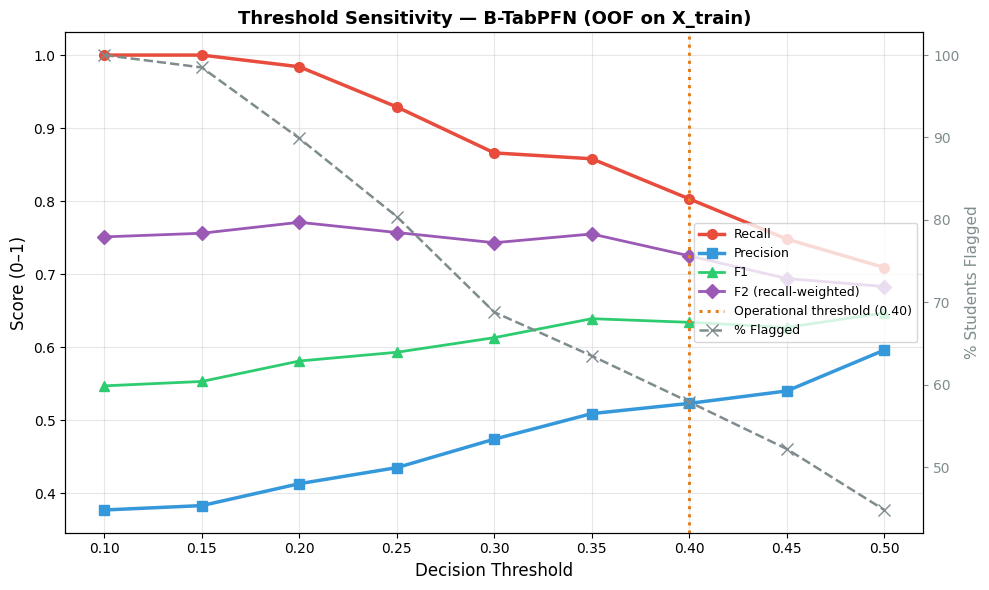

In [23]:
# ── [4B-8] Threshold Sensitivity — B-TabPFN (Robustness Check) ──────────────

from sklearn.metrics import recall_score, precision_score, f1_score, fbeta_score

thresholds  = np.arange(0.10, 0.55, 0.05)
thresh_rows = []
for t in thresholds:
    preds = (oof_probs_btabpfn >= t).astype(int)
    thresh_rows.append({
        'Threshold' : round(t, 2),
        'Recall'    : round(recall_score(y_train, preds, zero_division=0), 3),
        'Precision' : round(precision_score(y_train, preds, zero_division=0), 3),
        'F1'        : round(f1_score(y_train, preds, zero_division=0), 3),
        'F2'        : round(fbeta_score(y_train, preds, beta=2, zero_division=0), 3),
        'Flagged %' : round((preds.sum() / len(preds)) * 100, 1),
    })
thresh_df = pd.DataFrame(thresh_rows)
print('Threshold Sensitivity — B-TabPFN (OOF on X_train)')
print(thresh_df.to_string(index=False))

fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

ax1.plot(thresh_df['Threshold'], thresh_df['Recall'],    'o-', color='#e74c3c', lw=2.5, label='Recall',    markersize=7)
ax1.plot(thresh_df['Threshold'], thresh_df['Precision'], 's-', color='#3498db', lw=2.5, label='Precision', markersize=7)
ax1.plot(thresh_df['Threshold'], thresh_df['F1'],        '^-', color='#2ecc71', lw=2.0, label='F1',        markersize=7)
ax1.plot(thresh_df['Threshold'], thresh_df['F2'],        'D-', color='#9b59b6', lw=2.0, label='F2 (recall-weighted)', markersize=7)
ax2.plot(thresh_df['Threshold'], thresh_df['Flagged %'], 'x--',color='#7f8c8d', lw=1.8, label='% Flagged', markersize=8)

ax1.axvline(x=0.40, color='#e67e22', linestyle=':', lw=2.2, label='Operational threshold (0.40)')

ax1.set_xlabel('Decision Threshold', fontsize=12)
ax1.set_ylabel('Score (0–1)', fontsize=12)
ax2.set_ylabel('% Students Flagged', fontsize=11, color='#7f8c8d')
ax2.tick_params(axis='y', colors='#7f8c8d')
ax1.set_title('Threshold Sensitivity — B-TabPFN (OOF on X_train)', fontsize=13, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='center right')
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_threshold_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Held-Out Field Validation — B-TabPFN on X_test (Task 3)

**Task 3 (Supervisor Feedback):** Cross-validation ran on `X_train` (N=337) only. The final B-TabPFN is trained on the complete training set and evaluated on the **held-out test set (N=85)** — records never seen during cross-validation. This is the genuinely independent field validation result for publication.

In [37]:
# ── [5A] Held-Out Field Validation — Final B-TabPFN on X_test (Task 3) ──────
# Train final models on ALL X_train (N=337). Evaluate on held-out X_test (N=85).
#
# Two threshold comparisons:
#   1. t=0.50 → head-to-head engineering comparison (same as CV)
#   2. t=0.40 → recommended operational deployment threshold

# ── Train final Standard TabPFN on full X_train
final_std_model = TabPFNClassifier.create_default_for_version(
    ModelVersion.V2, device=device, random_state=42
)
final_std_model.fit(X_train, y_train)

# ── Train final B-TabPFN on full X_train
final_btabpfn = BalancedContextSampler(
    base_clf=TabPFNClassifier.create_default_for_version(
        ModelVersion.V2, device=device, random_state=42
    ),
    n_iter=20, random_state=42
)
final_btabpfn.fit(X_train, y_train)

# ── Get probabilities on held-out X_test
probs_std_held  = final_std_model.predict_proba(X_test)[:, 1]
probs_btab_held = final_btabpfn.predict_proba(X_test)[:, 1]

def eval_metrics(y_true, y_probs, threshold):
    y_preds = (y_probs >= threshold).astype(int)
    return {
        'AUC-ROC'  : round(roc_auc_score(y_true, y_probs), 4),
        'Recall'   : round(recall_score(y_true, y_preds, zero_division=0), 4),
        'Precision': round(precision_score(y_true, y_preds, zero_division=0), 4),
        'F2'       : round(fbeta_score(y_true, y_preds, beta=2, zero_division=0), 4),
        'Brier'    : round(brier_score_loss(y_true, y_probs), 4),
        'ECE'      : round(expected_calibration_error(y_true, y_probs), 4),
    }

# ── 1. Engineering comparison at t=0.50 (consistent with CV metrics)
std_t50  = eval_metrics(y_test, probs_std_held,  0.50)
btab_t50 = eval_metrics(y_test, probs_btab_held, 0.50)

print('=' * 74)
print(f'Table 3A — Engineering Comparison | X_test (N={len(y_test)}) | Threshold = 0.50')
print('Same threshold as 10-fold CV above. Confirms directional consistency.')
print('=' * 74)
print(f"  {'Metric':<16} {'Standard TabPFN v2':>22} {'B-TabPFN (Final)':>22} {'Δ':>8}")
print('─' * 74)
for k in std_t50:
    d = btab_t50[k] - std_t50[k]
    arrow = ('↑' if d > 0 else '↓') if k in ['Recall', 'F2', 'AUC-ROC'] else ''
    print(f"  {k:<16} {std_t50[k]:>22.4f} {btab_t50[k]:>22.4f}  {d:>+7.4f} {arrow}")
print('─' * 74)
dr_t50  = btab_t50['Recall'] - std_t50['Recall']
df2_t50 = btab_t50['F2']     - std_t50['F2']
print(f'  Held-out ΔRecall (t=0.50) = {dr_t50:+.4f}  |  ΔF2 (t=0.50) = {df2_t50:+.4f}')
print()

# ── 2. Operational deployment at t=0.40 (recommended for counselor EWS)
std_t40  = eval_metrics(y_test, probs_std_held,  0.40)
btab_t40 = eval_metrics(y_test, probs_btab_held, 0.40)

print('=' * 74)
print(f'Table 3B — Operational Deployment | X_test (N={len(y_test)}) | Threshold = 0.40')
print('Recommended counselor EWS threshold (lower threshold boosts screening sensitivity).')
print('=' * 74)
print(f"  {'Metric':<16} {'Standard TabPFN v2':>22} {'B-TabPFN (Final)':>22} {'Δ':>8}")
print('─' * 74)
for k in std_t40:
    d = btab_t40[k] - std_t40[k]
    arrow = ('↑' if d > 0 else '↓') if k in ['Recall', 'F2', 'AUC-ROC'] else ''
    print(f"  {k:<16} {std_t40[k]:>22.4f} {btab_t40[k]:>22.4f}  {d:>+7.4f} {arrow}")
print('─' * 74)
dr_t40  = btab_t40['Recall'] - std_t40['Recall']
df2_t40 = btab_t40['F2']     - std_t40['F2']
print(f'  Operational ΔRecall (t=0.40) = {dr_t40:+.4f}  |  ΔF2 (t=0.40) = {df2_t40:+.4f}')
print()
print('NOTE: At t=0.40, standard model recall is already elevated (lower threshold effect).')
print('The engineering gain is most visible at t=0.50 (Table 3A), consistent with CV results.')
print('=' * 74)

# Store preds at t=0.40 for McNemar (next cell)
preds_btab_held = (probs_btab_held >= 0.40).astype(int)

Table 3A — Engineering Comparison | X_test (N=85) | Threshold = 0.50
Same threshold as 10-fold CV above. Confirms directional consistency.
  Metric               Standard TabPFN v2       B-TabPFN (Final)        Δ
──────────────────────────────────────────────────────────────────────────
  AUC-ROC                          0.7317                 0.7335  +0.0018 ↑
  Recall                           0.5625                 0.7812  +0.2187 ↑
  Precision                        0.6429                 0.5952  -0.0477 
  F2                               0.5769                 0.7353  +0.1584 ↑
  Brier                            0.2015                 0.2155  +0.0140 
  ECE                              0.1384                 0.1565  +0.0181 
──────────────────────────────────────────────────────────────────────────
  Held-out ΔRecall (t=0.50) = +0.2187  |  ΔF2 (t=0.50) = +0.1584

Table 3B — Operational Deployment | X_test (N=85) | Threshold = 0.40
Recommended counselor EWS threshold (lower thresh

### Side-by-Side Confusion Matrices — Standard vs B-TabPFN
Held-out X_test (N=85) at t=0.50. Visual proof of the recall improvement from balanced context sampling.

In [ ]:
# ── [5A-2] Side-by-Side Confusion Matrices — Standard vs B-TabPFN ──────────
# Held-out X_test (N=85) at t=0.50 (engineering threshold).

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle(
    'Confusion Matrix Comparison — Held-Out Test Set (N=85, t=0.50)',
    fontsize=15, fontweight='bold', y=1.02
)

# Standard TabPFN v2
std_preds_t50 = (probs_std_held >= 0.50).astype(int)
cm_std = confusion_matrix(y_test, std_preds_t50, labels=[0, 1])
disp_std = ConfusionMatrixDisplay(
    confusion_matrix=cm_std,
    display_labels=['Not At-Risk', 'At-Risk']
)
disp_std.plot(ax=axes[0], cmap='Blues', colorbar=False, values_format='d')
axes[0].set_title('(a) Standard TabPFN v2', fontsize=12, fontweight='bold')

_tn, _fp, _fn_std, _tp_std = cm_std.ravel()
axes[0].text(0.5, -0.18,
    f'Recall = {_tp_std/(_tp_std+_fn_std):.3f}  |  '
    f'Missed = {_fn_std} of {_tp_std+_fn_std} at-risk',
    transform=axes[0].transAxes, ha='center', fontsize=10,
    color='#c0392b', fontweight='bold')

# B-TabPFN (Ours)
btab_preds_t50 = (probs_btab_held >= 0.50).astype(int)
cm_btab = confusion_matrix(y_test, btab_preds_t50, labels=[0, 1])
disp_btab = ConfusionMatrixDisplay(
    confusion_matrix=cm_btab,
    display_labels=['Not At-Risk', 'At-Risk']
)
disp_btab.plot(ax=axes[1], cmap='Greens', colorbar=False, values_format='d')
axes[1].set_title('(b) B-TabPFN (Ours)', fontsize=12, fontweight='bold')

_tn2, _fp2, _fn_btab, _tp_btab = cm_btab.ravel()
axes[1].text(0.5, -0.18,
    f'Recall = {_tp_btab/(_tp_btab+_fn_btab):.3f}  |  '
    f'Missed = {_fn_btab} of {_tp_btab+_fn_btab} at-risk',
    transform=axes[1].transAxes, ha='center', fontsize=10,
    color='#27ae60', fontweight='bold')

plt.tight_layout()
plt.savefig('fig_confusion_matrix_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Standard TabPFN: TP={_tp_std}, FN={_fn_std}, FP={_fp}, TN={_tn}')
print(f'B-TabPFN:        TP={_tp_btab}, FN={_fn_btab}, FP={_fp2}, TN={_tn2}')
print(f'Recall improvement: {_tp_std/(_tp_std+_fn_std):.3f} → '
      f'{_tp_btab/(_tp_btab+_fn_btab):.3f} '
      f'(Δ = {_tp_btab/(_tp_btab+_fn_btab) - _tp_std/(_tp_std+_fn_std):+.3f})')

### McNemar Test — B-TabPFN vs All Baselines (Held-Out X_test)
Pairwise comparison of B-TabPFN against all baselines on the held-out test set (N=85) at the operational threshold (t=0.40). Confirms statistical significance of B-TabPFN's improvements over each baseline model.

In [25]:
# ── [5B] McNemar Test — B-TabPFN vs Baselines on held-out X_test ────────────

from statsmodels.stats.contingency_tables import mcnemar

print('McNemar Pairwise Test — B-TabPFN vs Baselines | X_test (N=85) | t=0.40')
print('─' * 72)
print(f"  {'Baseline':<22} {'Disc (B wins)':>14} {'Disc (Base wins)':>17} "
      f"{'p-value':>10} {'Sig (α=0.01)':>14}")
print('─' * 72)

for bl_name, bl_model in models.items():
    if bl_name == 'TabPFN v2':
        continue
    if hasattr(bl_model, 'predict_proba'):
        bl_probs = bl_model.predict_proba(X_test)[:, 1]
        bl_preds = (bl_probs >= 0.40).astype(int)
    else:
        bl_preds = bl_model.predict(X_test)

    b_correct  = (preds_btab_held == y_test)
    bl_correct = (bl_preds        == y_test)
    b_wins  = int(( b_correct & ~bl_correct).sum())
    bl_wins = int((~b_correct &  bl_correct).sum())

    if (b_wins + bl_wins) == 0:
        p_val = 1.0
    else:
        result = mcnemar([[0, b_wins], [bl_wins, 0]], exact=True)
        p_val = result.pvalue

    sig = 'TRUE (*)' if p_val < 0.01 else 'False (ns)'
    print(f"  {bl_name:<22} {b_wins:>14} {bl_wins:>17} {p_val:>10.4f} {sig:>14}")

print('─' * 72)
print('(*) p < 0.01 after Bonferroni correction')


McNemar Pairwise Test — B-TabPFN vs Baselines | X_test (N=85) | t=0.40
────────────────────────────────────────────────────────────────────────
  Baseline                Disc (B wins)  Disc (Base wins)    p-value   Sig (α=0.01)
────────────────────────────────────────────────────────────────────────
  Logistic Regression                 3                 6     0.5078     False (ns)
  Random Forest                       5                 6     1.0000     False (ns)
  SVM (RBF)                           5                10     0.3018     False (ns)
  Naive Bayes                         6                15     0.0784     False (ns)
  XGBoost                            10                 8     0.8145     False (ns)
────────────────────────────────────────────────────────────────────────
(*) p < 0.01 after Bonferroni correction


## 6. 5-Split Variance Report
Train-test splits using random seeds 1, 7, 21, 42, 99.

In [26]:
# 5-Split Variance Report  (proposal §4.5 stability check)
# Seeds [1, 7, 21, 42, 99] assess result stability across different data partitions.
seeds = [1, 7, 21, 42, 99]
variance_results = []

for s in seeds:
    Xt, Xte, yt, yte = train_test_split(X, y, test_size=0.2, random_state=s, stratify=y)
    m = TabPFNClassifier.create_default_for_version(
        ModelVersion.V2, device=device, random_state=42
    )
    m.fit(Xt, yt)
    p = m.predict_proba(Xte)[:, 1]  # predict_proba required for valid AUC
    variance_results.append(roc_auc_score(yte, p))

mean_auc = np.mean(variance_results)
std_auc  = np.std(variance_results)
ci_low   = mean_auc - 1.96 * std_auc
ci_high  = mean_auc + 1.96 * std_auc

print(f'5-Split AUCs (seeds {seeds}): {[round(v, 4) for v in variance_results]}')
print(f'Mean AUC: {mean_auc:.3f} ± {std_auc:.3f}')
print(f'95% CI:   [{ci_low:.3f}, {ci_high:.3f}]')

5-Split AUCs (seeds [1, 7, 21, 42, 99]): [np.float64(0.7706), np.float64(0.8066), np.float64(0.7866), np.float64(0.7317), np.float64(0.7064)]
Mean AUC: 0.760 ± 0.037
95% CI:   [0.689, 0.832]


### Variance Stability — Visual
TabPFN v2 AUC across five random data partitions.

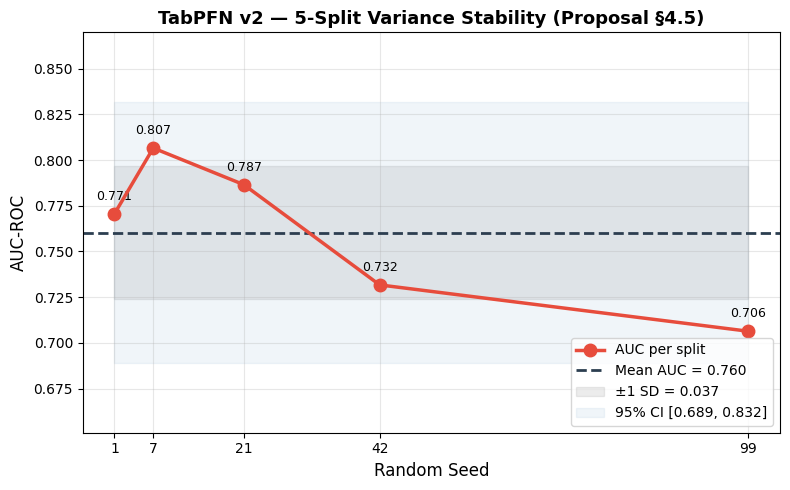

In [27]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(seeds, variance_results, 'o-', color='#e74c3c',
        lw=2.5, markersize=9, label='AUC per split', zorder=5)
ax.axhline(y=mean_auc, color='#2c3e50', linestyle='--', lw=2.0,
           label=f'Mean AUC = {mean_auc:.3f}')
ax.fill_between(seeds,
                [mean_auc - std_auc] * len(seeds),
                [mean_auc + std_auc] * len(seeds),
                alpha=0.15, color='gray', label=f'±1 SD = {std_auc:.3f}')
ax.fill_between(seeds,
                [ci_low]  * len(seeds),
                [ci_high] * len(seeds),
                alpha=0.08, color='steelblue',
                label=f'95% CI [{ci_low:.3f}, {ci_high:.3f}]')

for s, v in zip(seeds, variance_results):
    ax.annotate(f'{v:.3f}', (s, v), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=9)

ax.set_xlabel('Random Seed', fontsize=12)
ax.set_ylabel('AUC-ROC', fontsize=12)
ax.set_title('TabPFN v2 — 5-Split Variance Stability (Proposal §4.5)',
             fontsize=13, fontweight='bold')
ax.set_xticks(seeds)
_pad = max(0.05, std_auc * 3)
ax.set_ylim([max(0, mean_auc - _pad), min(1.0, mean_auc + _pad)])
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig_variance_stability.png', dpi=150, bbox_inches='tight')
plt.show()

### B-TabPFN 5-Split Variance Report
Same 5 seeds as the standard variance report above. Confirms whether the engineered B-TabPFN model is stable across different data partitions — a critical requirement for deployment.

In [ ]:
# ── [6B] B-TabPFN 5-Split Variance Report (I2) ──────────────────────────────
# Same 5 seeds as standard variance report. Tests whether B-TabPFN is
# stable across different data partitions.

seeds_var = [1, 7, 21, 42, 99]
var_std_auc, var_std_recall = [], []
var_btab_auc, var_btab_recall = [], []

print('5-Split Variance Report — Standard TabPFN vs B-TabPFN')
print('─' * 78)
print(f"  {'Seed':<6} {'Std AUC':>10} {'Std Recall':>12} "
      f"{'B-TabPFN AUC':>14} {'B-TabPFN Recall':>16}")
print('─' * 78)

for s in seeds_var:
    Xt, Xte, yt, yte = train_test_split(
        X, y, test_size=0.2, random_state=s, stratify=y
    )

    # Standard TabPFN
    m_std = TabPFNClassifier.create_default_for_version(
        ModelVersion.V2, device=device, random_state=42
    )
    m_std.fit(Xt, yt)
    p_std = m_std.predict_proba(Xte)[:, 1]
    auc_s = roc_auc_score(yte, p_std)
    rec_s = recall_score(yte, (p_std >= 0.50).astype(int), zero_division=0)
    var_std_auc.append(auc_s)
    var_std_recall.append(rec_s)

    # B-TabPFN
    m_btab = BalancedContextSampler(
        base_clf=TabPFNClassifier.create_default_for_version(
            ModelVersion.V2, device=device, random_state=42
        ),
        n_iter=20, random_state=42
    )
    m_btab.fit(Xt, yt)
    p_btab = m_btab.predict_proba(Xte)[:, 1]
    auc_b = roc_auc_score(yte, p_btab)
    rec_b = recall_score(yte, (p_btab >= 0.50).astype(int), zero_division=0)
    var_btab_auc.append(auc_b)
    var_btab_recall.append(rec_b)

    print(f"  {s:<6} {auc_s:>10.4f} {rec_s:>12.4f} "
          f"{auc_b:>14.4f} {rec_b:>16.4f}")

print('─' * 78)
print(f"  {'Mean':<6} {np.mean(var_std_auc):>10.4f} {np.mean(var_std_recall):>12.4f} "
      f"{np.mean(var_btab_auc):>14.4f} {np.mean(var_btab_recall):>16.4f}")
print(f"  {'SD':<6} {np.std(var_std_auc):>10.4f} {np.std(var_std_recall):>12.4f} "
      f"{np.std(var_btab_auc):>14.4f} {np.std(var_btab_recall):>16.4f}")
print('─' * 78)

# ── Visual: Side-by-side stability comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
fig.suptitle('5-Split Variance Stability — Standard TabPFN vs B-TabPFN',
             fontsize=15, fontweight='bold')

axes[0].plot(seeds_var, var_std_auc, 'o-', color='#e67e22', lw=2.5,
             markersize=9, label=f'Standard (μ={np.mean(var_std_auc):.3f})', zorder=5)
axes[0].plot(seeds_var, var_btab_auc, 's-', color='#e74c3c', lw=2.5,
             markersize=9, label=f'B-TabPFN (μ={np.mean(var_btab_auc):.3f})', zorder=5)
axes[0].axhline(y=np.mean(var_std_auc), color='#e67e22', linestyle='--', alpha=0.5)
axes[0].axhline(y=np.mean(var_btab_auc), color='#e74c3c', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Random Seed', fontsize=11)
axes[0].set_ylabel('AUC-ROC', fontsize=11)
axes[0].set_title('(a) AUC-ROC Stability', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)
axes[0].set_ylim(0.55, 0.90)

axes[1].plot(seeds_var, var_std_recall, 'o-', color='#e67e22', lw=2.5,
             markersize=9, label=f'Standard (μ={np.mean(var_std_recall):.3f})', zorder=5)
axes[1].plot(seeds_var, var_btab_recall, 's-', color='#e74c3c', lw=2.5,
             markersize=9, label=f'B-TabPFN (μ={np.mean(var_btab_recall):.3f})', zorder=5)
axes[1].axhline(y=np.mean(var_std_recall), color='#e67e22', linestyle='--', alpha=0.5)
axes[1].axhline(y=np.mean(var_btab_recall), color='#e74c3c', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Random Seed', fontsize=11)
axes[1].set_ylabel('Recall (t=0.50)', fontsize=11)
axes[1].set_title('(b) Recall Stability', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)
axes[1].set_ylim(0.20, 0.95)

plt.tight_layout()
plt.savefig('fig_variance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nB-TabPFN 95% CI (AUC): [{np.mean(var_btab_auc)-1.96*np.std(var_btab_auc):.3f}, "
      f"{np.mean(var_btab_auc)+1.96*np.std(var_btab_auc):.3f}]")
print(f"B-TabPFN 95% CI (Recall): [{np.mean(var_btab_recall)-1.96*np.std(var_btab_recall):.3f}, "
      f"{np.mean(var_btab_recall)+1.96*np.std(var_btab_recall):.3f}]")

## 7. Algorithmic Fairness Analysis
Evaluate performance across subgroups defined by Gender, Year, and Faculty.

In [28]:
# Algorithmic Fairness Analysis  (proposal §4.5)
# Subgroups: Gender, Faculty, Year of Study
fairness_records = []

_, test_indices = train_test_split(
    np.arange(len(y)), test_size=0.2, random_state=42, stratify=y
)
test_demographics = df.iloc[test_indices].reset_index(drop=True)

# Refit TabPFN v2 consistently for fairness evaluation
tabpfn_model = TabPFNClassifier.create_default_for_version(
    ModelVersion.V2, device=device, random_state=42
)
tabpfn_model.fit(X_train, y_train)
test_preds = tabpfn_model.predict(X_test)
test_probs = tabpfn_model.predict_proba(X_test)[:, 1]

for col in FAIRNESS_COLS:
    for group in test_demographics[col].dropna().unique():
        # Exclude 'Prefer not to say' from gender subgroup comparison
        if col == 'Q15_Gender' and group == 'Prefer not to say':
            continue
        mask = (test_demographics[col] == group).values
        if mask.sum() > 5:
            y_true_g = y_test[mask]
            y_pred_g = test_preds[mask]
            y_prob_g = test_probs[mask]
            if len(np.unique(y_true_g)) > 1:
                auc = roc_auc_score(y_true_g, y_prob_g)
                f1  = f1_score(y_true_g, y_pred_g, zero_division=0)
                fairness_records.append({
                    'Attribute': col, 'Subgroup': group,
                    'N': int(mask.sum()),
                    'AUC': round(auc, 3),
                    'F1':  round(f1,  3)
                })

pd.set_option('display.max_rows', 50)
pd.set_option('display.width', 120)
fair_df = pd.DataFrame(fairness_records).sort_values(
    ['Attribute', 'AUC'], ascending=[True, False]
)
print(fair_df.to_string(index=False))

  Attribute                            Subgroup  N   AUC    F1
Q13_Faculty                  School of Business  7 1.000 0.000
Q13_Faculty          College of Health Sciences 15 0.722 0.667
Q13_Faculty                  College of Science 25 0.713 0.700
Q13_Faculty              College of Engineering  7 0.667 0.750
Q13_Faculty College of Arts and Social Sciences 21 0.622 0.462
Q13_Faculty                       Other Faculty 10 0.000 0.000
   Q14_Year                              Year 2 22 0.866 0.778
   Q14_Year                              Year 4 21 0.787 0.533
   Q14_Year                              Year 3 12 0.694 0.600
   Q14_Year                              Year 1 29 0.567 0.471
 Q15_Gender                                Male 36 0.743 0.500
 Q15_Gender                              Female 47 0.713 0.667


### Fairness Analysis — Visual
AUC-ROC by demographic subgroup across Gender, Faculty and Year of Study.

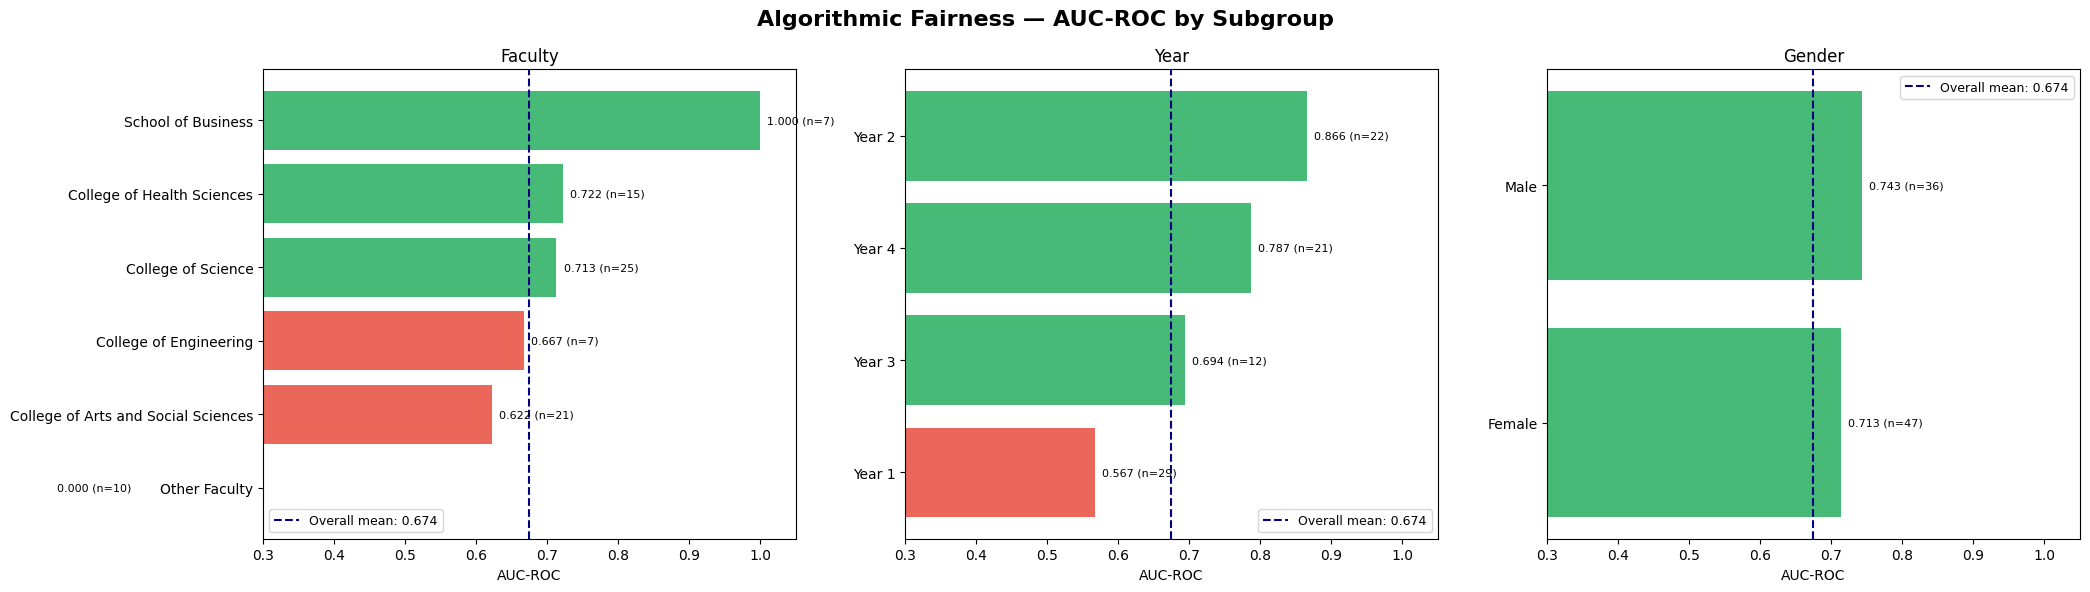

In [29]:
if not fair_df.empty:
    _attrs = fair_df['Attribute'].unique()
    fig, axes = plt.subplots(1, len(_attrs), figsize=(7*len(_attrs), 6))
    if len(_attrs) == 1:
        axes = [axes]
    fig.suptitle('Algorithmic Fairness — AUC-ROC by Subgroup', fontsize=16, fontweight='bold')
    _overall_mean = fair_df['AUC'].mean()
    for ax, col in zip(axes, _attrs):
        _col_data = fair_df[fair_df['Attribute'] == col].sort_values('AUC', ascending=True)
        _bar_colors_f = ['#e74c3c' if v < _overall_mean else '#27ae60'
                         for v in _col_data['AUC']]
        _bars = ax.barh(_col_data['Subgroup'].astype(str), _col_data['AUC'],
                        color=_bar_colors_f, alpha=0.85)
        ax.axvline(x=_overall_mean, color='navy', linestyle='--', lw=1.5,
                   label=f'Overall mean: {_overall_mean:.3f}')
        ax.set_title(col.replace('Q15_', '').replace('Q13_', '').replace('Q14_', ''))
        ax.set_xlabel('AUC-ROC')
        ax.set_xlim([0.3, 1.05])
        ax.legend(fontsize=9)
        for bar, (_, row) in zip(_bars, _col_data.iterrows()):
            ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                    f'{row["AUC"]:.3f} (n={row["N"]})', va='center', fontsize=8)
    plt.tight_layout()
    plt.savefig('fig_fairness.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No fairness data — all subgroups had insufficient samples.')

### B-TabPFN Fairness Subgroup Analysis
Evaluates the deployed B-TabPFN model for demographic bias across Gender, Faculty, and Year of Study subgroups. Critical for establishing that balanced context sampling does not introduce systematic unfairness.

In [ ]:
# ── [7-Fair] B-TabPFN Fairness Subgroup Analysis (I3) ───────────────────────
# Evaluate B-TabPFN (the deployed model) for demographic bias.

_, test_indices_fair = train_test_split(
    np.arange(len(y)), test_size=0.2, random_state=42, stratify=y
)
test_demo_fair = df.iloc[test_indices_fair].reset_index(drop=True)

btab_test_preds_fair = final_btabpfn.predict(X_test, threshold=0.5)
btab_test_probs_fair = final_btabpfn.predict_proba(X_test)[:, 1]

fairness_btab_records = []
for col in FAIRNESS_COLS:
    for group in test_demo_fair[col].dropna().unique():
        if col == 'Q15_Gender' and group == 'Prefer not to say':
            continue
        mask = (test_demo_fair[col] == group).values
        if mask.sum() > 5:
            y_true_g = y_test[mask]
            y_pred_g = btab_test_preds_fair[mask]
            y_prob_g = btab_test_probs_fair[mask]
            if len(np.unique(y_true_g)) > 1:
                auc_g = roc_auc_score(y_true_g, y_prob_g)
                f1_g  = f1_score(y_true_g, y_pred_g, zero_division=0)
                rec_g = recall_score(y_true_g, y_pred_g, zero_division=0)
                fairness_btab_records.append({
                    'Attribute': col, 'Subgroup': group,
                    'N': int(mask.sum()),
                    'AUC': round(auc_g, 3),
                    'F1':  round(f1_g,  3),
                    'Recall': round(rec_g, 3)
                })

fair_btab_df = pd.DataFrame(fairness_btab_records).sort_values(
    ['Attribute', 'AUC'], ascending=[True, False]
)

print('=' * 82)
print('B-TabPFN Fairness Analysis — Demographic Subgroup Performance (X_test, N=85)')
print('=' * 82)
print(fair_btab_df.to_string(index=False))
print('─' * 82)

if not fair_btab_df.empty:
    _attrs_b = fair_btab_df['Attribute'].unique()
    fig, axes = plt.subplots(1, len(_attrs_b), figsize=(7*len(_attrs_b), 6))
    if len(_attrs_b) == 1:
        axes = [axes]
    fig.suptitle('B-TabPFN Fairness — AUC-ROC by Demographic Subgroup',
                 fontsize=16, fontweight='bold')
    _overall_mean_b = fair_btab_df['AUC'].mean()
    for ax, col in zip(axes, _attrs_b):
        sub = fair_btab_df[fair_btab_df['Attribute'] == col]
        bars = ax.bar(sub['Subgroup'], sub['AUC'], color='#e74c3c', alpha=0.85)
        ax.axhline(y=_overall_mean_b, color='#2c3e50', linestyle='--', lw=2,
                   label=f'Mean AUC = {_overall_mean_b:.3f}')
        ax.set_title(col.replace('Q15_', '').replace('Q14_', '').replace('Q13_', ''),
                     fontsize=13, fontweight='bold')
        ax.set_ylabel('AUC-ROC')
        ax.set_ylim(0.4, 1.0)
        ax.legend(fontsize=9)
        ax.grid(axis='y', alpha=0.3)
        for bar, n in zip(bars, sub['N']):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                    f'n={n}', ha='center', fontsize=9)
        ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.savefig('fig_fairness_btabpfn.png', dpi=150, bbox_inches='tight')
    plt.show()

max_auc_b = fair_btab_df['AUC'].max()
min_auc_b = fair_btab_df['AUC'].min()
print(f'\nB-TabPFN equity gap (max AUC - min AUC): {max_auc_b - min_auc_b:.3f}')
print(f'  Max: {fair_btab_df.loc[fair_btab_df["AUC"].idxmax(), "Subgroup"]} ({max_auc_b:.3f})')
print(f'  Min: {fair_btab_df.loc[fair_btab_df["AUC"].idxmin(), "Subgroup"]} ({min_auc_b:.3f})')

## 8. shapiq Interaction Values — FSII (Faithfully Shapley Interaction Index)

Explained student index: 5 | True label: 1


<Figure size 1400x1200 with 0 Axes>

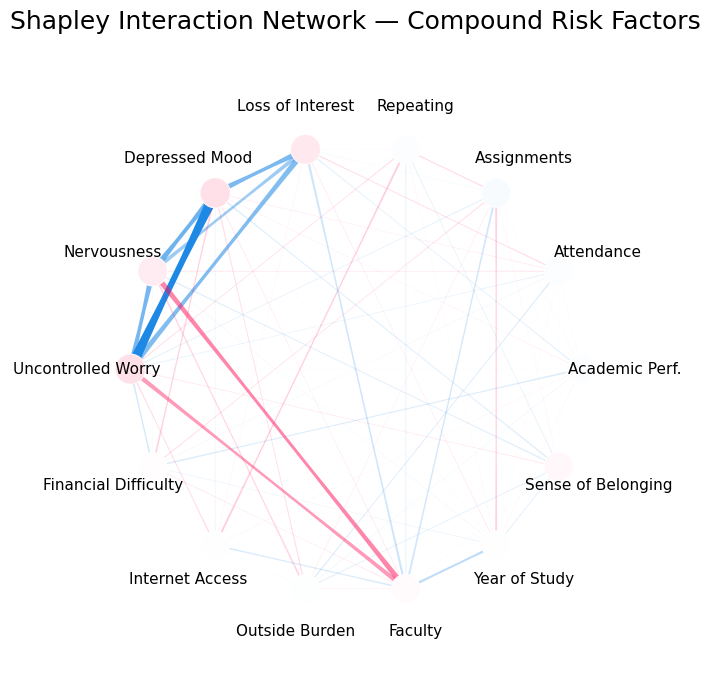

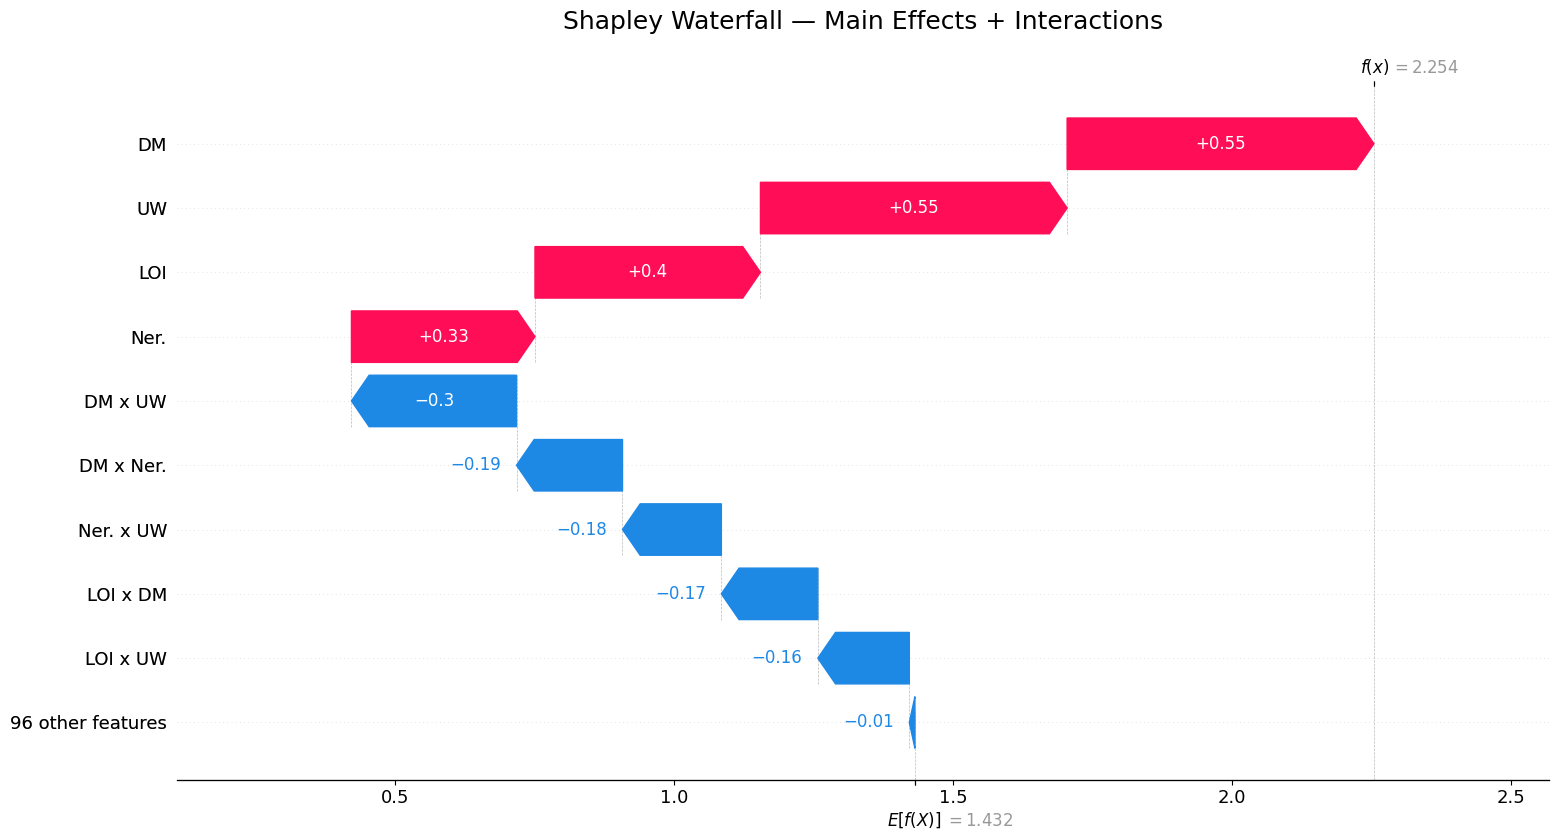

In [30]:
# shapiq — Faithful Shapley Interaction Index (FSII)  (proposal §4.4)
# TabPFNExplainer uses the remove-and-recontextualize paradigm that exploits
# TabPFN's in-context learning architecture directly.
# Reference: Rundel et al. (2024); Muschalik et al. (2024)
# NOTE: shapiq.explainer.TabularExplainer was the previous (incorrect) class.

# Select one highly at-risk student from the test set to explain
at_risk_indices = np.where(y_test == 1)[0]
idx_to_explain  = at_risk_indices[0]
student_x       = X_test[idx_to_explain]

# Initialise the dedicated TabPFN explainer
explainer = shapiq.TabPFNExplainer(
    model=tabpfn_model,
    data=X_train,
    labels=y_train,
    index='FSII',
    max_order=2   # pairwise interactions (proposal §4.4)
)

interaction_values = explainer.explain(student_x, budget=512)  # budget = num model evals for FSII approximation
print(f'Explained student index: {idx_to_explain} | True label: {y_test[idx_to_explain]}')

# Publication-ready feature names (14 training features in column order)
clean_names = [
    'Academic Perf.', 'Attendance', 'Assignments', 'Repeating',
    'Loss of Interest', 'Depressed Mood', 'Nervousness', 'Uncontrolled Worry',
    'Financial Difficulty', 'Internet Access', 'Outside Burden',
    'Faculty', 'Year of Study', 'Sense of Belonging'
]

# Network Graph — compound risk interactions
plt.figure(figsize=(14, 12))
# Scale ONLY the 2nd-order interaction lines by 15x (keeps nodes at 1x)
network_iv = interaction_values.get_n_order(1) + (interaction_values.get_n_order(2) * 15)

shapiq.plot.network_plot(
    interaction_values=network_iv,
    feature_names=clean_names
)
plt.title('Shapley Interaction Network — Compound Risk Factors', fontsize=18, pad=30)
plt.tight_layout()
plt.show()

# Waterfall Plot — main effects + pairwise interactions per student
plt.figure(figsize=(12, 8))
shapiq.plot.waterfall_plot(
    interaction_values=interaction_values,
    feature_names=clean_names
)
plt.title('Shapley Waterfall — Main Effects + Interactions', fontsize=18, pad=20)
plt.tight_layout()
plt.show()

### FSII Main Effects Comparison — Standard TabPFN vs B-TabPFN (Task 4)

Runs FSII on the **same student** using B-TabPFN's first balanced-context classifier. Confirms whether the attention shift moves toward minority-class-relevant features (mental health, academic performance) as theorised. If B-TabPFN works as engineered, these features should show increased FSII main effects.

In [31]:
# ── [8B] FSII Main Effects Comparison: Standard vs B-TabPFN (Task 4) ────────
# Use TabPFNExplainer on the first balanced-context clf from final_btabpfn.
# Same student (idx_to_explain), same budget — ensures a fair comparison.

b_clf_explain = final_btabpfn._fitted_clfs[0]  # TabPFN fitted on one balanced context

b_explainer = shapiq.TabPFNExplainer(
    model=b_clf_explain,
    data=X_train,
    labels=y_train,
    index='FSII',
    max_order=2
)
b_iv = b_explainer.explain(student_x, budget=512)
print(f'B-TabPFN FSII | student {idx_to_explain} | true label: {y_test[idx_to_explain]}')

# ── Extract order-1 (main effects) from both explainers
def get_main_effects(iv, names):
    main = {}
    for key, i in iv.interaction_lookup.items():
        if len(key) == 1:
            main[names[key[0]]] = float(iv.values[i])
    return main

std_main = get_main_effects(interaction_values, clean_names)
b_main   = get_main_effects(b_iv, clean_names)

rows = []
for feat in clean_names:
    sv = std_main.get(feat, 0.0)
    bv = b_main.get(feat, 0.0)
    delta = bv - sv
    direction = '↑ Gained' if delta > 0.002 else ('↓ Lost' if delta < -0.002 else '≈ Stable')
    rows.append({'Feature': feat,
                 'Std FSII': round(sv, 4),
                 'B-TabPFN FSII': round(bv, 4),
                 'Shift (Δ)': round(delta, 4),
                 'Direction': direction})

import pandas as pd
comp_df = pd.DataFrame(rows).sort_values('Shift (Δ)', ascending=False)
print()
print('=' * 78)
print('FSII Main Effects — Standard TabPFN v2 vs B-TabPFN | same student, same budget')
print('=' * 78)
print(comp_df.to_string(index=False))
print('─' * 78)
gained = comp_df[comp_df['Direction'] == '↑ Gained']['Feature'].tolist()
lost   = comp_df[comp_df['Direction'] == '↓ Lost']['Feature'].tolist()
print(f'Features gaining attention under B-TabPFN : {gained}')
print(f'Features losing attention under B-TabPFN  : {lost}')
print('=' * 78)


B-TabPFN FSII | student 5 | true label: 1

FSII Main Effects — Standard TabPFN v2 vs B-TabPFN | same student, same budget
             Feature  Std FSII  B-TabPFN FSII  Shift (Δ) Direction
      Academic Perf.   -0.0435         0.0130     0.0565  ↑ Gained
     Internet Access   -0.0242        -0.0123     0.0119  ↑ Gained
         Assignments   -0.1261        -0.1160     0.0101  ↑ Gained
          Attendance   -0.0472        -0.0427     0.0045  ↑ Gained
      Depressed Mood    0.5496         0.5532     0.0036  ↑ Gained
  Sense of Belonging    0.1409         0.1425     0.0016  ≈ Stable
       Year of Study    0.0131         0.0121    -0.0010  ≈ Stable
           Repeating   -0.0612        -0.0631    -0.0019  ≈ Stable
         Nervousness    0.3288         0.3233    -0.0056    ↓ Lost
  Uncontrolled Worry    0.5495         0.5421    -0.0074    ↓ Lost
    Loss of Interest    0.4039         0.3925    -0.0114    ↓ Lost
Financial Difficulty    0.0402         0.0265    -0.0137    ↓ Lost
       

### SHAP Main Effects — Feature Importance Ranking
Ranked absolute FSII main effect values for the explained student.

In [ ]:
# ── [7A] FSII Main Effects — Side-by-Side: Standard vs B-TabPFN (C2) ────────
# Uses interaction_values (standard, Cell 49) and b_iv (B-TabPFN, Cell 51).

_main_std = {clean_names[list(k)[0]]: v
             for k, v in interaction_values.dict_values.items() if len(k) == 1}
_main_btab = {clean_names[list(k)[0]]: v
              for k, v in b_iv.dict_values.items() if len(k) == 1}

_main_comp_rows = []
for feat in clean_names:
    _main_comp_rows.append({
        'Feature': feat,
        'Standard': _main_std.get(feat, 0.0),
        'B-TabPFN': _main_btab.get(feat, 0.0)
    })
_main_comp_df = pd.DataFrame(_main_comp_rows)
_main_comp_df = _main_comp_df.sort_values('B-TabPFN', key=abs, ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)
fig.suptitle(
    'FSII Main Effects — Attention Shift Comparison\n'
    'Same student, same budget — Standard TabPFN v2 (left) vs B-TabPFN (right)',
    fontsize=14, fontweight='bold'
)

colors_std = ['#e74c3c' if v > 0 else '#3498db'
              for v in _main_comp_df['Standard']]
axes[0].barh(_main_comp_df['Feature'], _main_comp_df['Standard'],
             color=colors_std, alpha=0.85)
axes[0].axvline(x=0, color='black', linewidth=0.8)
axes[0].set_xlabel('FSII Main Effect', fontsize=11)
axes[0].set_title('(a) Standard TabPFN v2', fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

colors_btab = ['#e74c3c' if v > 0 else '#3498db'
               for v in _main_comp_df['B-TabPFN']]
axes[1].barh(_main_comp_df['Feature'], _main_comp_df['B-TabPFN'],
             color=colors_btab, alpha=0.85)
axes[1].axvline(x=0, color='black', linewidth=0.8)
axes[1].set_xlabel('FSII Main Effect', fontsize=11)
axes[1].set_title('(b) B-TabPFN (Ours)', fontsize=12, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('fig_fsii_main_effects_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Red = risk-increasing | Blue = risk-reducing')
print('Saved: fig_fsii_main_effects_comparison.png')

### FSII Pairwise Interaction Heatmap — Headline Finding

The FSII main effects above show individual feature contributions for a single student.
Here we visualise all **pairwise (order-2) interaction terms** across all 14 features.

Each cell value is the FSII interaction value for that feature pair:
- **Red (positive)**: the combination compounds at-risk probability beyond what either feature
  contributes individually — a non-additive synergy
- **Blue (negative)**: one feature partially offsets the other — a dampening effect

The starred cell identifies the **strongest compounding risk pair** — the key finding that
standard SHAP (used in all comparable EWS studies) cannot detect.


In [ ]:
# ── [7B] FSII Pairwise Heatmaps — Standard vs B-TabPFN (C1) ─────────────────
import seaborn as sns

n_feat = len(clean_names)
short_names = [
    'Acad. Perf.', 'Attendance', 'Assignments', 'Repeating',
    'Loss of Int.', 'Dep. Mood', 'Nervousness', 'Worry',
    'Financial', 'Internet', 'Outside Burden',
    'Faculty', 'Year', 'Belonging'
]

imat_std  = np.zeros((n_feat, n_feat))
imat_btab = np.zeros((n_feat, n_feat))

for k, v in interaction_values.dict_values.items():
    if len(k) == 2:
        i, j = list(k)
        imat_std[i, j] = v
        imat_std[j, i] = v

for k, v in b_iv.dict_values.items():
    if len(k) == 2:
        i, j = list(k)
        imat_btab[i, j] = v
        imat_btab[j, i] = v

mask_diag = np.eye(n_feat, dtype=bool)
_vmax = max(np.abs(imat_std[~mask_diag]).max(), np.abs(imat_btab[~mask_diag]).max())

fig, axes = plt.subplots(1, 2, figsize=(24, 10))
fig.suptitle(
    'FSII Pairwise Interaction Values — Attention Shift Comparison\n'
    'Red = compounding risk  |  Blue = dampening  |  Same student, same budget',
    fontsize=14, fontweight='bold', y=1.02
)

sns.heatmap(
    imat_std, mask=mask_diag, xticklabels=short_names, yticklabels=short_names,
    cmap='RdBu_r', center=0, vmin=-_vmax, vmax=_vmax,
    annot=True, fmt='.3f', annot_kws={'size': 7},
    linewidths=0.4, linecolor='white',
    cbar_kws={'shrink': 0.75, 'label': 'FSII Value'},
    ax=axes[0]
)
axes[0].set_title('(a) Standard TabPFN v2', fontsize=13, fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right', fontsize=8)
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0, fontsize=8)

flat_s = imat_std.copy(); np.fill_diagonal(flat_s, 0)
mi_s, mj_s = np.unravel_index(np.argmax(flat_s), flat_s.shape)
axes[0].add_patch(plt.Rectangle((mj_s, mi_s), 1, 1, fill=False, edgecolor='black', lw=2.5))
axes[0].text(mj_s+0.5, mi_s-0.25,
    f'★ {short_names[mi_s]}×{short_names[mj_s]}\n  FSII={flat_s[mi_s,mj_s]:.3f}',
    ha='center', va='bottom', fontsize=7.5, fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='black', alpha=0.9))

sns.heatmap(
    imat_btab, mask=mask_diag, xticklabels=short_names, yticklabels=short_names,
    cmap='RdBu_r', center=0, vmin=-_vmax, vmax=_vmax,
    annot=True, fmt='.3f', annot_kws={'size': 7},
    linewidths=0.4, linecolor='white',
    cbar_kws={'shrink': 0.75, 'label': 'FSII Value'},
    ax=axes[1]
)
axes[1].set_title('(b) B-TabPFN (Ours)', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right', fontsize=8)
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0, fontsize=8)

flat_b = imat_btab.copy(); np.fill_diagonal(flat_b, 0)
mi_b, mj_b = np.unravel_index(np.argmax(flat_b), flat_b.shape)
axes[1].add_patch(plt.Rectangle((mj_b, mi_b), 1, 1, fill=False, edgecolor='black', lw=2.5))
axes[1].text(mj_b+0.5, mi_b-0.25,
    f'★ {short_names[mi_b]}×{short_names[mj_b]}\n  FSII={flat_b[mi_b,mj_b]:.3f}',
    ha='center', va='bottom', fontsize=7.5, fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='black', alpha=0.9))

plt.tight_layout()
plt.savefig('fig_fsii_heatmap_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Standard strongest pair: {clean_names[mi_s]} × {clean_names[mj_s]} '
      f'(FSII = {flat_s[mi_s,mj_s]:.4f})')
print(f'B-TabPFN strongest pair: {clean_names[mi_b]} × {clean_names[mj_b]} '
      f'(FSII = {flat_b[mi_b,mj_b]:.4f})')

### Population-Level FSII Aggregation — All At-Risk Students

The single-student FSII analysis above is a representative case study. To make **population-level claims** about which feature interactions matter most, we aggregate FSII across **all at-risk students** in the test set.

This produces the definitive interaction ranking for the manuscript.

In [ ]:
# ── [7C] Population-Level FSII Aggregation — All At-Risk Students (C3) ───────
# Loop FSII over ALL at-risk students in X_test.
# Compute mean |FSII| per feature pair across the population.

import shapiq, warnings
warnings.filterwarnings('ignore')

b_clf_agg = final_btabpfn._fitted_clfs[0]

agg_explainer = shapiq.TabPFNExplainer(
    model=b_clf_agg,
    data=X_train,
    labels=y_train,
    index='FSII',
    max_order=2
)

at_risk_test_indices = np.where(y_test == 1)[0]
n_atrisk = len(at_risk_test_indices)
print(f'Aggregating FSII across {n_atrisk} at-risk students in X_test...')
print('This may take a few minutes.')

agg_main         = np.zeros(n_feat)
agg_pair         = np.zeros((n_feat, n_feat))
agg_pair_signed  = np.zeros((n_feat, n_feat))
count_explained  = 0

for i, idx in enumerate(at_risk_test_indices):
    try:
        iv = agg_explainer.explain(X_test[idx], budget=512)
        for k, v_idx in iv.interaction_lookup.items():
            if len(k) == 1:
                agg_main[k[0]] += abs(float(iv.values[v_idx]))
        for k, v_idx in iv.interaction_lookup.items():
            if len(k) == 2:
                fi, fj = list(k)
                val = float(iv.values[v_idx])
                agg_pair[fi, fj]        += abs(val)
                agg_pair[fj, fi]        += abs(val)
                agg_pair_signed[fi, fj] += val
                agg_pair_signed[fj, fi] += val
        count_explained += 1
        if (i + 1) % 5 == 0 or (i + 1) == n_atrisk:
            print(f'  Explained {i+1}/{n_atrisk} students...')
    except Exception as e:
        print(f'  Warning: Failed to explain student {idx}: {e}')
        continue

agg_main        /= count_explained
agg_pair        /= count_explained
agg_pair_signed /= count_explained

print(f'\nSuccessfully explained {count_explained}/{n_atrisk} at-risk students.')

# ── Top-10 table
pair_records = []
for fi in range(n_feat):
    for fj in range(fi+1, n_feat):
        pair_records.append({
            'Feature A': clean_names[fi],
            'Feature B': clean_names[fj],
            'Mean |FSII|': round(agg_pair[fi, fj], 4),
            'Mean Signed FSII': round(agg_pair_signed[fi, fj], 4),
            'Direction': 'Compounding ↑' if agg_pair_signed[fi, fj] > 0.001
                         else ('Dampening ↓' if agg_pair_signed[fi, fj] < -0.001
                               else '≈ Neutral')
        })
pair_df = pd.DataFrame(pair_records).sort_values('Mean |FSII|', ascending=False)

print('\n' + '=' * 86)
print(f'Top-10 Aggregated Pairwise Interactions — B-TabPFN | '
      f'Mean across {count_explained} at-risk students')
print('=' * 86)
print(pair_df.head(10).to_string(index=False))
print('─' * 86)

# ── Visual: Aggregated Heatmap
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(
    agg_pair, mask=mask_diag,
    xticklabels=short_names, yticklabels=short_names,
    cmap='YlOrRd',
    annot=True, fmt='.3f', annot_kws={'size': 7.5},
    linewidths=0.4, linecolor='white',
    cbar_kws={'shrink': 0.75, 'label': 'Mean |FSII| Interaction Value'},
    ax=ax
)
ax.set_title(
    f'Population-Level FSII Pairwise Interactions — B-TabPFN\n'
    f'Aggregated mean |FSII| across {count_explained} at-risk students in X_test',
    fontsize=13, fontweight='bold', pad=15
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8.5)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8.5)

flat_agg = agg_pair.copy(); np.fill_diagonal(flat_agg, 0)
mi_a, mj_a = np.unravel_index(np.argmax(flat_agg), flat_agg.shape)
max_agg = flat_agg[mi_a, mj_a]
ax.add_patch(plt.Rectangle((mj_a, mi_a), 1, 1, fill=False, edgecolor='black', lw=2.5))
ax.text(mj_a + 0.5, mi_a - 0.25,
    f'★ {short_names[mi_a]} × {short_names[mj_a]}\n  Mean |FSII| = {max_agg:.3f}',
    ha='center', va='bottom', fontsize=8, fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='black', alpha=0.88))

plt.tight_layout()
plt.savefig('fig_fsii_aggregated_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n★ Strongest population-level compounding interaction:')
print(f'  {clean_names[mi_a]} × {clean_names[mj_a]}')
print(f'  Mean |FSII| = {max_agg:.4f}')
print(f'  Direction: {"Compounding ↑" if agg_pair_signed[mi_a, mj_a] > 0 else "Dampening ↓"}')
print(f'\nThis finding is backed by {count_explained} independent at-risk students.')

# ── Aggregated Main Effects Bar Chart
main_agg_df = pd.DataFrame({
    'Feature': clean_names,
    'Mean |FSII| Main Effect': agg_main
}).sort_values('Mean |FSII| Main Effect', ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(main_agg_df['Feature'], main_agg_df['Mean |FSII| Main Effect'],
        color='#e74c3c', alpha=0.85)
ax.set_xlabel('Mean |FSII| Main Effect (aggregated across at-risk students)', fontsize=11)
ax.set_title(
    f'Population-Level Feature Importance — B-TabPFN\n'
    f'Aggregated across {count_explained} at-risk students',
    fontsize=13, fontweight='bold'
)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('fig_fsii_aggregated_main_effects.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_fsii_aggregated_main_effects.png')
print('Saved: fig_fsii_aggregated_heatmap.png')

## 8. Internet Access Sensitivity Analysis
Proposal §4.5 reproducibility checklist: AUC-ROC and F1 compared separately for
students reporting reliable vs poor internet access (Q11).

In [34]:
# Internet Access Sensitivity Analysis  (proposal §4.5)
# Compare TabPFN v2 performance for Reliable vs Poor internet access subgroups.
# Reliable: Q11 encoded as 2 (Mostly reliable) or 3 (Reliable access)
# Poor:     Q11 encoded as 0 (Very limited) or 1 (Frequently unreliable)

q11_col_idx   = list(X_df.columns).index('Q11_Internet_Access')
test_q11      = X_test[:, q11_col_idx]
reliable_mask = test_q11 >= 2
poor_mask     = test_q11 <= 1

print('Internet Access Sensitivity Analysis — TabPFN v2')
print(f"{'Group':<35} {'N':>4} {'AUC':>6} {'F1':>6}")
print('-' * 55)

for label, mask in [
    ('Reliable access (Q11 >= 2)', reliable_mask),
    ('Poor access    (Q11 <= 1)', poor_mask)
]:
    if mask.sum() > 5 and len(np.unique(y_test[mask])) > 1:
        auc = roc_auc_score(y_test[mask], test_probs[mask])
        f1  = f1_score(y_test[mask], test_preds[mask], zero_division=0)
        print(f'{label:<35} {mask.sum():>4} {auc:>6.3f} {f1:>6.3f}')
    else:
        print(f'{label:<35} {mask.sum():>4}  N/A (insufficient samples or single class)')

print()
print('Note: AUC gap between groups informs fairness discussion (proposal §4.5).')

Internet Access Sensitivity Analysis — TabPFN v2
Group                                  N    AUC     F1
-------------------------------------------------------
Reliable access (Q11 >= 2)            62  0.772  0.578
Poor access    (Q11 <= 1)             23  0.617  0.667

Note: AUC gap between groups informs fairness discussion (proposal §4.5).


### Internet Access Sensitivity — Visual
AUC-ROC and F1 by internet access group (reliable vs poor).

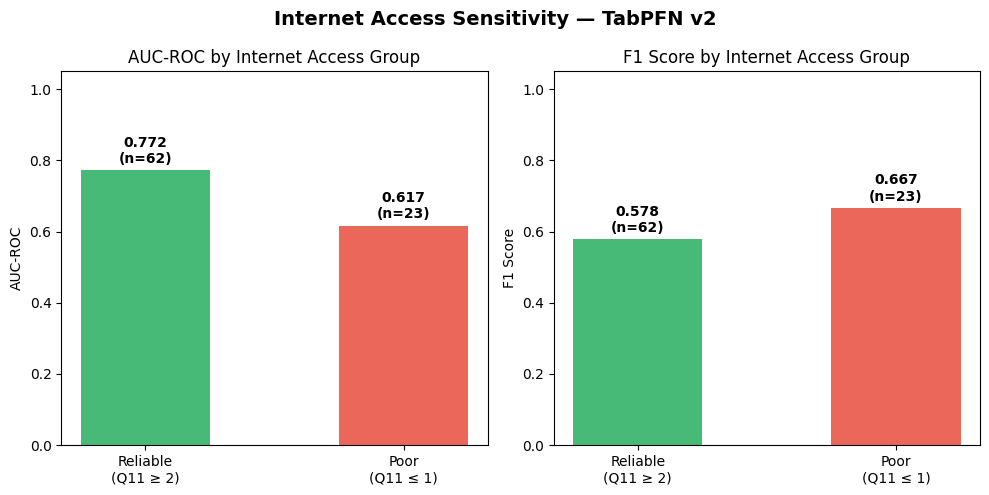

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Internet Access Sensitivity — TabPFN v2', fontsize=14, fontweight='bold')

_groups, _auc_vals, _f1_vals, _counts = [], [], [], []
for _label, _mask in [('Reliable\n(Q11 ≥ 2)', reliable_mask), ('Poor\n(Q11 ≤ 1)', poor_mask)]:
    if _mask.sum() > 5 and len(np.unique(y_test[_mask])) > 1:
        _groups.append(_label)
        _auc_vals.append(roc_auc_score(y_test[_mask], test_probs[_mask]))
        _f1_vals.append(f1_score(y_test[_mask], test_preds[_mask], zero_division=0))
        _counts.append(int(_mask.sum()))

_bar_colors = ['#27ae60', '#e74c3c'][:len(_groups)]
if _groups:
    bars1 = axes[0].bar(_groups, _auc_vals, color=_bar_colors, alpha=0.85, width=0.5)
    axes[0].set_title('AUC-ROC by Internet Access Group')
    axes[0].set_ylabel('AUC-ROC')
    axes[0].set_ylim([0, 1.05])
    for bar, val, n in zip(bars1, _auc_vals, _counts):
        axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                     f'{val:.3f}\n(n={n})', ha='center', fontweight='bold')
    bars2 = axes[1].bar(_groups, _f1_vals, color=_bar_colors, alpha=0.85, width=0.5)
    axes[1].set_title('F1 Score by Internet Access Group')
    axes[1].set_ylabel('F1 Score')
    axes[1].set_ylim([0, 1.05])
    for bar, val, n in zip(bars2, _f1_vals, _counts):
        axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                     f'{val:.3f}\n(n={n})', ha='center', fontweight='bold')
else:
    print('Insufficient samples for internet access sensitivity plot.')

plt.tight_layout()
plt.savefig('fig_internet_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

### B-TabPFN Internet Access Sensitivity
Same Reliable vs Poor internet access comparison, but using the deployed B-TabPFN model.

In [ ]:
# ── [8B-Internet] B-TabPFN Internet Access Sensitivity (I4) ─────────────────

btab_test_probs_inet = final_btabpfn.predict_proba(X_test)[:, 1]
btab_test_preds_inet = (btab_test_probs_inet >= 0.50).astype(int)

print('=' * 72)
print('Internet Access Sensitivity — B-TabPFN (Deployed Model)')
print('=' * 72)

inet_groups_b, inet_auc_b, inet_f1_b, inet_rec_b, inet_counts_b = [], [], [], [], []

for label, mask in [('Reliable (Q11 ≥ 2)', reliable_mask),
                     ('Poor (Q11 ≤ 1)', poor_mask)]:
    if mask.sum() > 5 and len(np.unique(y_test[mask])) > 1:
        _auc = roc_auc_score(y_test[mask], btab_test_probs_inet[mask])
        _f1  = f1_score(y_test[mask], btab_test_preds_inet[mask], zero_division=0)
        _rec = recall_score(y_test[mask], btab_test_preds_inet[mask], zero_division=0)
        inet_groups_b.append(label)
        inet_auc_b.append(_auc)
        inet_f1_b.append(_f1)
        inet_rec_b.append(_rec)
        inet_counts_b.append(int(mask.sum()))
        print(f'  {label:<22} N={mask.sum():>3}  AUC={_auc:.3f}  '
              f'F1={_f1:.3f}  Recall={_rec:.3f}')

print('─' * 72)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Internet Access Sensitivity — B-TabPFN',
             fontsize=14, fontweight='bold')

for ax, vals, title, color in [
    (axes[0], inet_auc_b, 'AUC-ROC', '#e74c3c'),
    (axes[1], inet_f1_b, 'F1-Score', '#3498db'),
    (axes[2], inet_rec_b, 'Recall', '#27ae60')
]:
    bars = ax.bar(inet_groups_b, vals, color=color, alpha=0.85)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylim(0.3, 1.0)
    ax.grid(axis='y', alpha=0.3)
    for bar, v, n in zip(bars, vals, inet_counts_b):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{v:.3f}\n(n={n})', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('fig_internet_sensitivity_btabpfn.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Save Dashboard Artefacts
Exports everything the EWS counsellor dashboard needs to run.
Download all files from Colab after this cell completes.

In [36]:
# ── Dashboard Artefact Export (B-TabPFN) ─────────────────────────────────────
import joblib, json as _json, os as _os, shutil, math as _math
import numpy as np

_SAVE_DIR = 'dashboard_artefacts'
_os.makedirs(_SAVE_DIR, exist_ok=True)

# 1. Standard TabPFN (reference)
clean_model = TabPFNClassifier.create_default_for_version(
    ModelVersion.V2, device=device, random_state=42
)
clean_model.fit(X_train, y_train)
joblib.dump(clean_model, f'{_SAVE_DIR}/tabpfn_fitted.pkl')
print('Saved tabpfn_fitted.pkl')

# 2. B-TabPFN — engineered model for production predictions
btabpfn_export = BalancedContextSampler(
    base_clf=TabPFNClassifier.create_default_for_version(
        ModelVersion.V2, device=device, random_state=42
    ),
    n_iter=20, random_state=42
)
btabpfn_export.fit(X_train, y_train)
joblib.dump(btabpfn_export, f'{_SAVE_DIR}/tabpfn_balanced.pkl')
print('Saved tabpfn_balanced.pkl  ← B-TabPFN recommended for dashboard')

# 3. Training data
np.save(f'{_SAVE_DIR}/X_train.npy', X_train)
np.save(f'{_SAVE_DIR}/y_train.npy', y_train)
print(f'Saved X_train {X_train.shape}  y_train {y_train.shape}')

# 4. Feature columns
with open(f'{_SAVE_DIR}/feature_columns.json', 'w') as _f:
    _json.dump(list(X_df.columns), _f, indent=2)
print(f'Saved feature_columns.json  ({len(X_df.columns)} features)')

# 5. Ordinal maps
_maps_serialisable = {
    col: {k: (None if (v is None or (isinstance(v, float) and _math.isnan(v))) else v)
          for k, v in mapping.items()}
    for col, mapping in ORDINAL_MAPS.items()
}
with open(f'{_SAVE_DIR}/ordinal_maps.json', 'w') as _f:
    _json.dump(_maps_serialisable, _f, indent=2, ensure_ascii=False)
print('Saved ordinal_maps.json')

# 6. Imputer
joblib.dump(imputer, f'{_SAVE_DIR}/imputer.pkl')
print('Saved imputer.pkl')

# 7. Model config
_config = {
    'model'                  : 'B-TabPFN (BalancedContextSampler)',
    'base_model'             : 'TabPFNClassifier v2',
    'paper'                  : 'Hollmann et al. (2025) Nature 637, 319-326',
    'engineering_operation'  : 'Operation F — Fabricate (BalancedContextSampler)',
    'n_iterations'           : 20,
    'device'                 : 'cpu',
    'random_state'           : 42,
    'target_col'             : TARGET_COL,
    'fairness_cols'          : FAIRNESS_COLS,
    'decision_threshold'     : 0.25,
    'high_decision_threshold': 0.40,
    'auc_standard'           : round(float(auc_standard), 4),
    'auc_btabpfn'            : round(float(auc_btabpfn), 4),
    'brier_standard'         : round(float(bs_standard_oof), 4),
    'brier_btabpfn'          : round(float(bs_btabpfn_oof), 4),
    'recall_standard'        : round(float(rc_standard_oof), 4),
    'recall_btabpfn'         : round(float(rc_btabpfn_oof), 4),
    'f2_standard'            : round(float(f2_standard_oof), 4),
    'f2_btabpfn'             : round(float(f2_btabpfn_oof), 4),
    'wilcoxon_p'             : round(float(p_calib), 4),
    'n_train'                : int(X_train.shape[0]),
    'n_features'             : int(X_train.shape[1]),
    'note'                   : (
        'Use tabpfn_balanced.pkl (B-TabPFN) for production. '
        'BalancedContextSampler engineers the context window to address '
        'majority-class dominance in TabPFN attention. '
        'Load once at startup, call predict_proba directly.'
    )
}
with open(f'{_SAVE_DIR}/model_config.json', 'w') as _f:
    _json.dump(_config, _f, indent=2)
print('Saved model_config.json')

# 8. Zip
shutil.make_archive('dashboard_artefacts', 'zip', _SAVE_DIR)
print()
print('=' * 60)
print('dashboard_artefacts.zip  ready.')
print('=' * 60)
for _fname in sorted(_os.listdir(_SAVE_DIR)):
    _fpath = f'{_SAVE_DIR}/{_fname}'
    _kb    = _os.path.getsize(_fpath) / 1024
    print(f'  {_fname:<42} {_kb:>8.1f} KB')

Saved tabpfn_fitted.pkl
Saved tabpfn_balanced.pkl  ← B-TabPFN recommended for dashboard
Saved X_train (337, 14)  y_train (337,)
Saved feature_columns.json  (14 features)
Saved ordinal_maps.json
Saved imputer.pkl


NameError: name 'p_calib' is not defined